<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Illustration_of_Quantum_Transduction_Using_Heatmaps_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [5]:
!uv pip install -q "qutip==5.2.3" "cupy-cuda12x>=13,<14" graphviz


=== Environment ===
NumPy: 2.0.2
QuTiP import available: True
QuTiP: 5.2.3
CuPy GPU available: True
CuPy: 13.6.0
CUDA device: Tesla T4
Graphviz import available: True


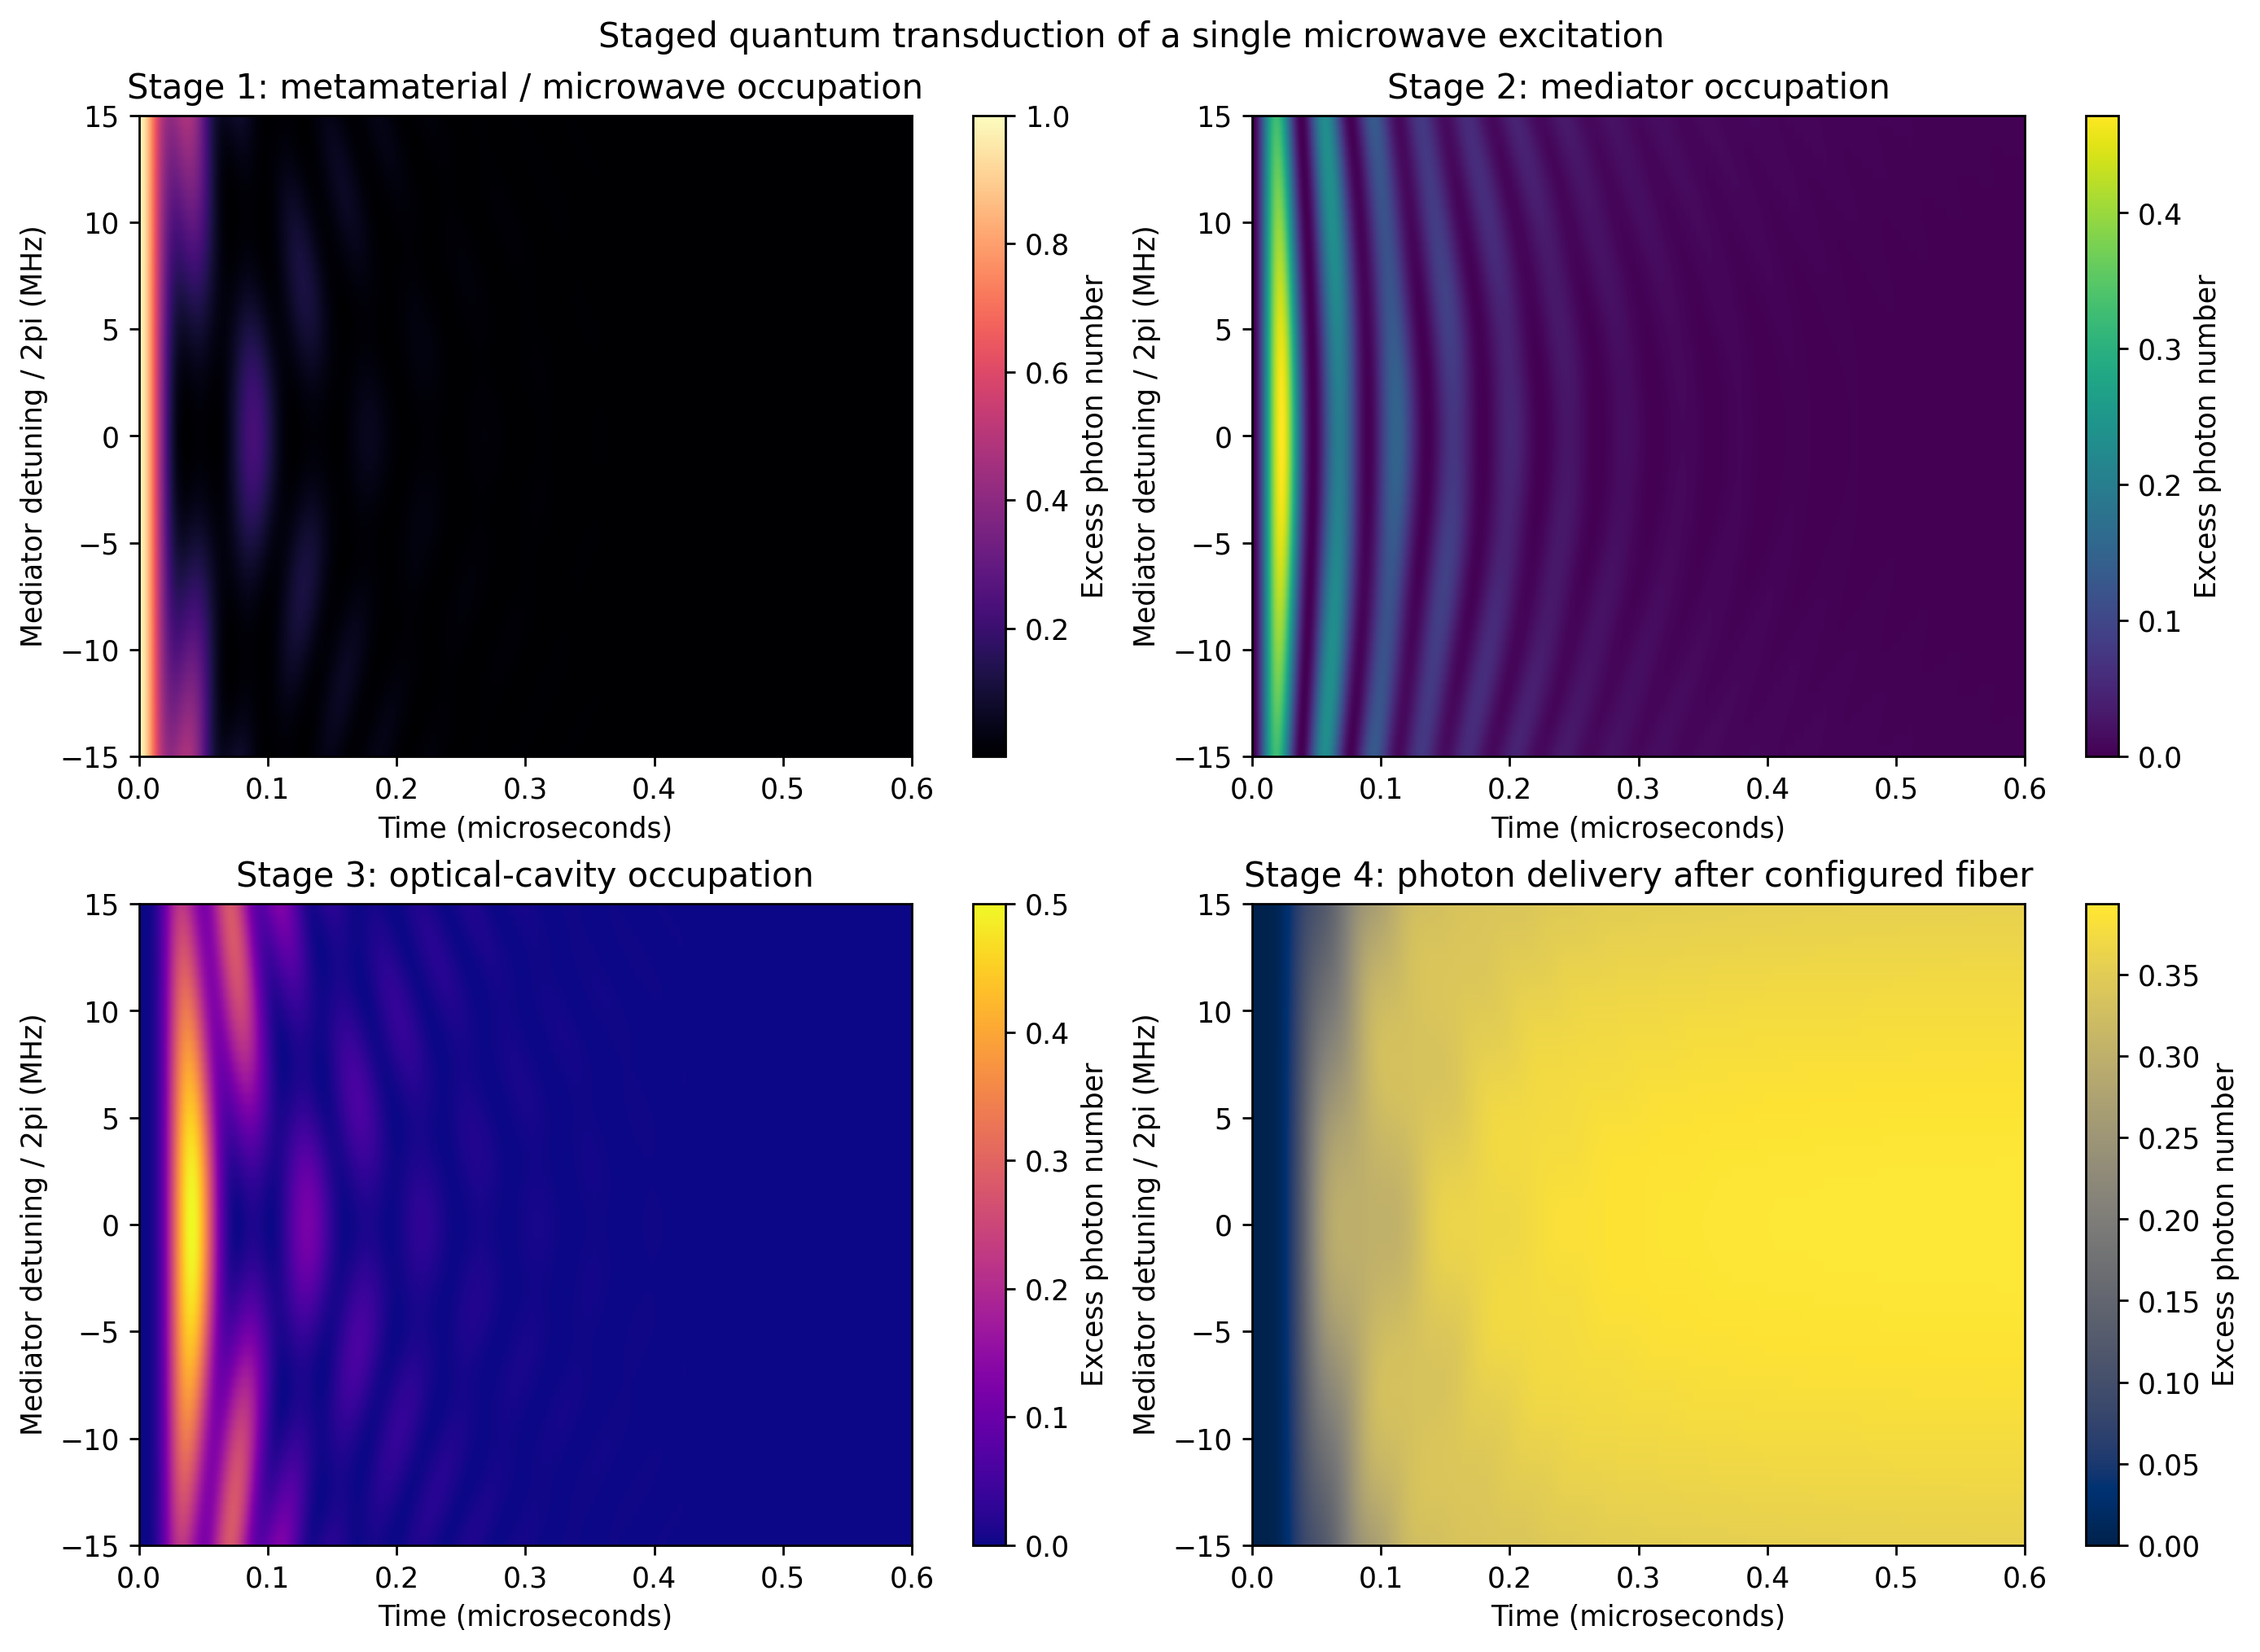

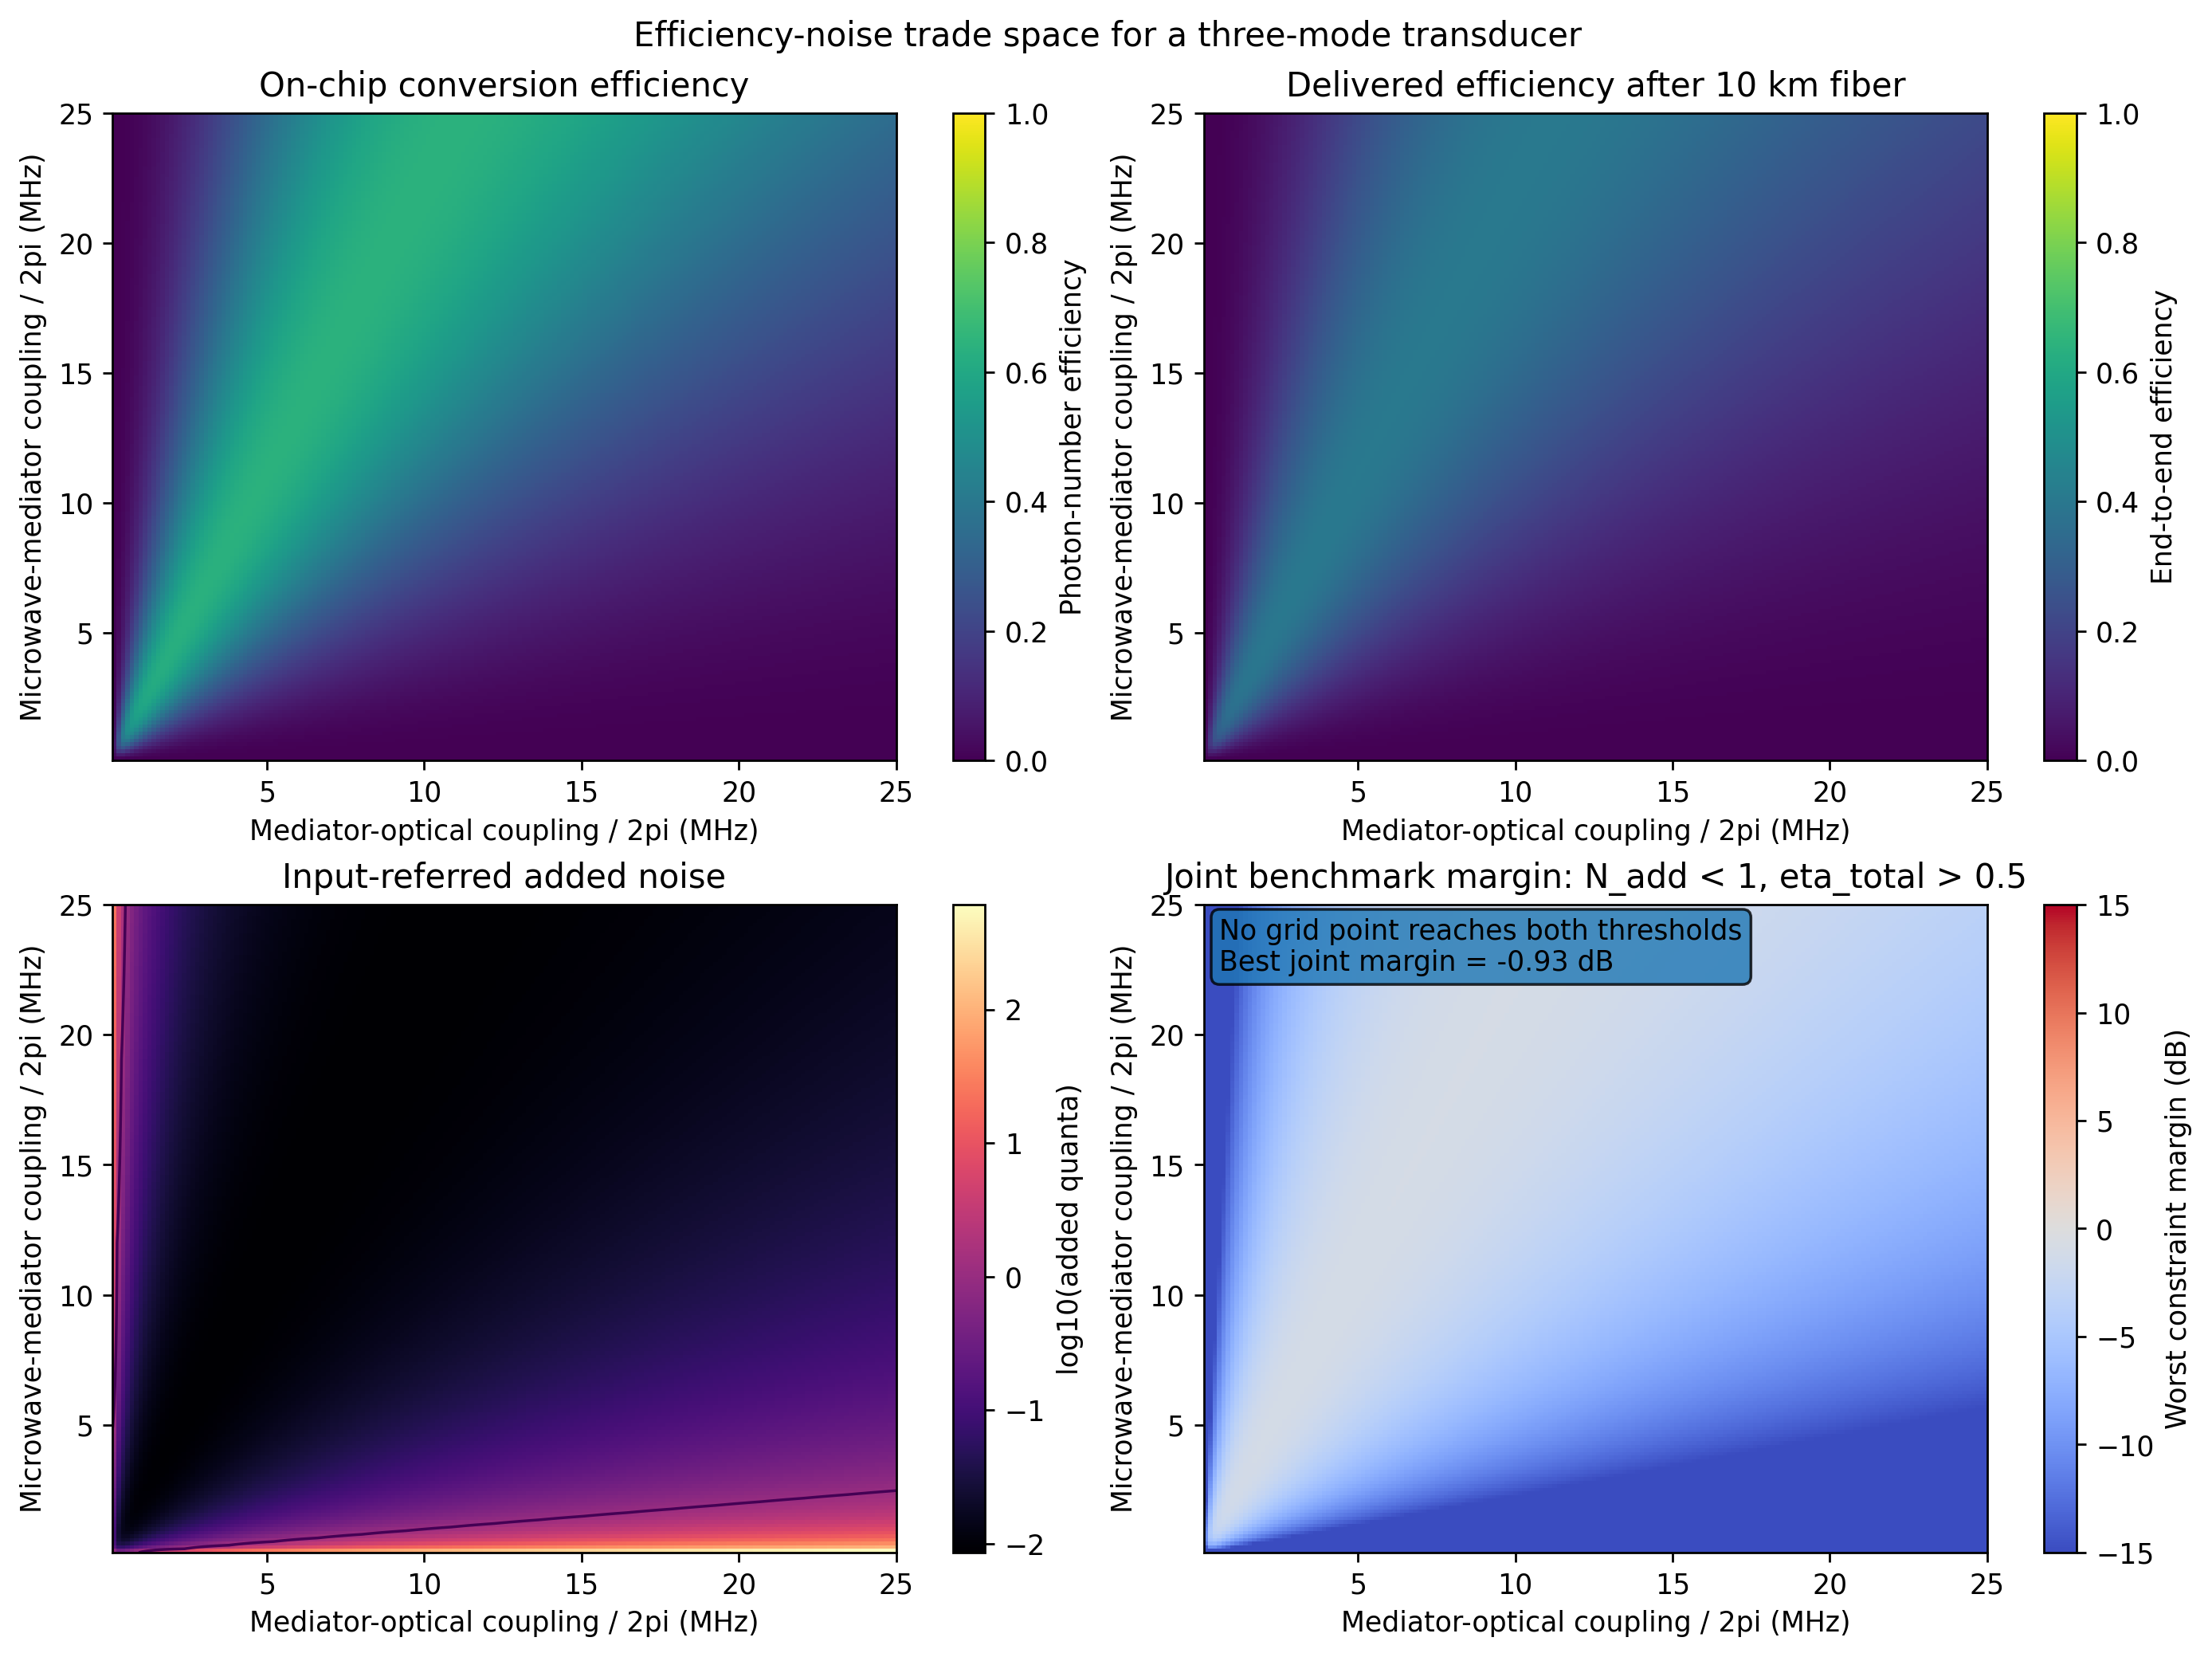

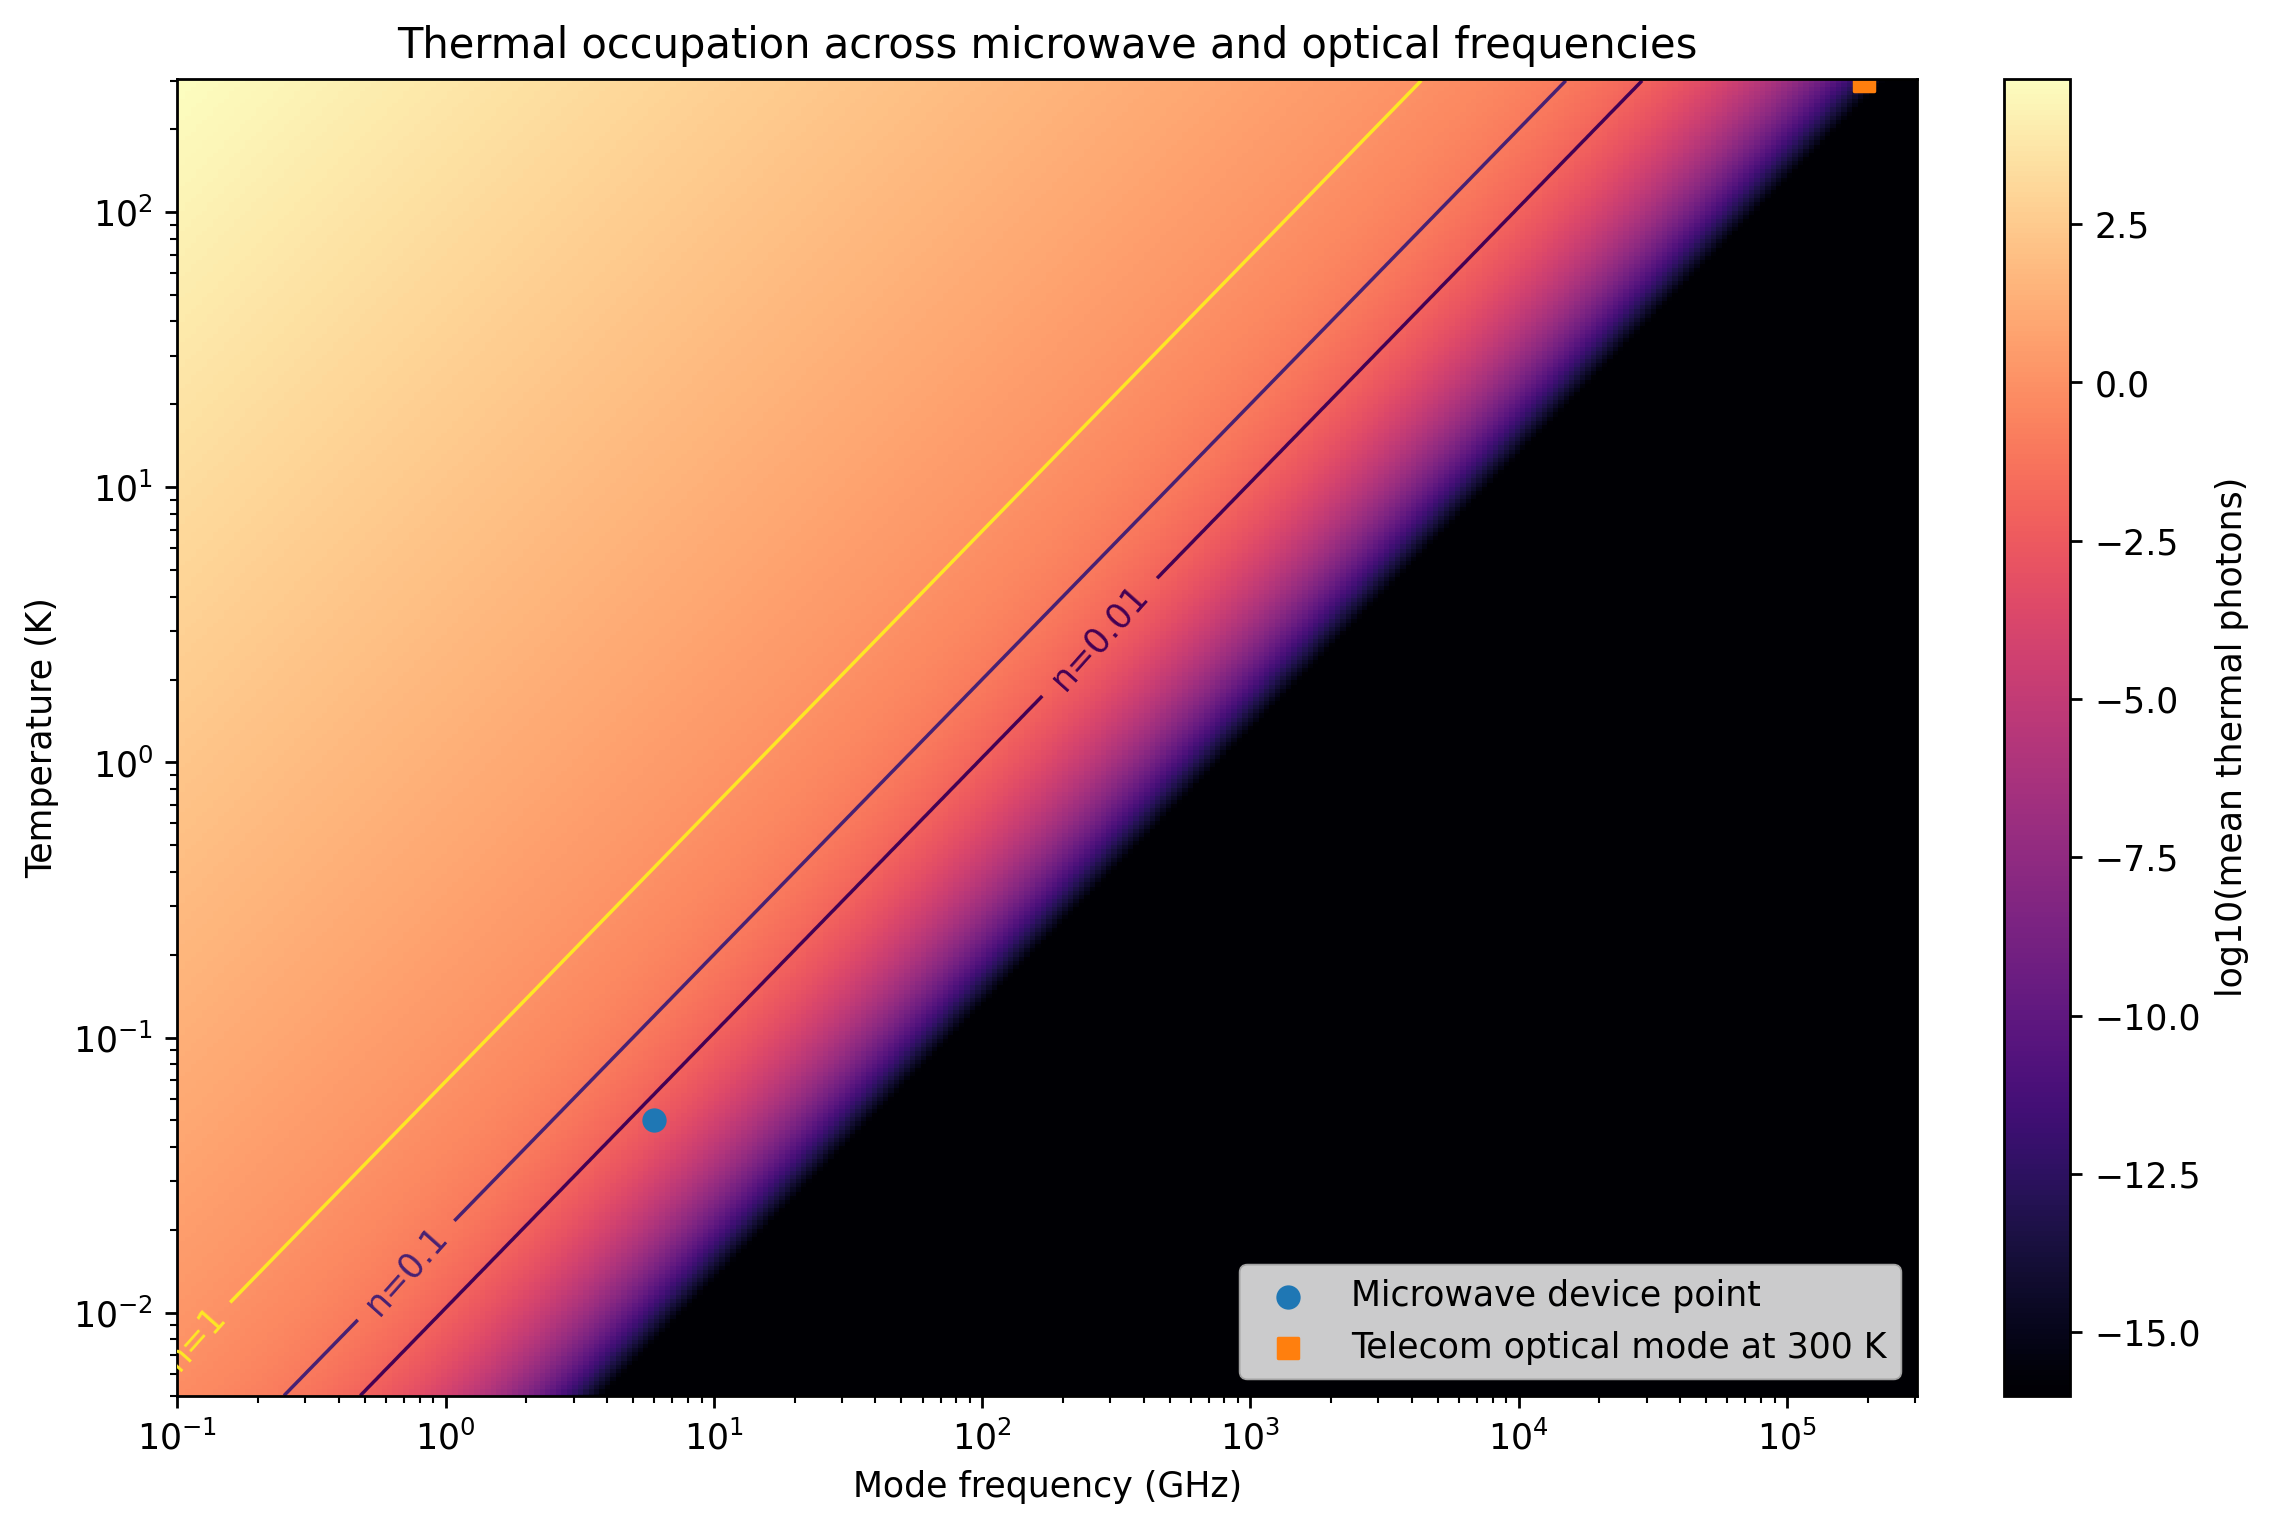

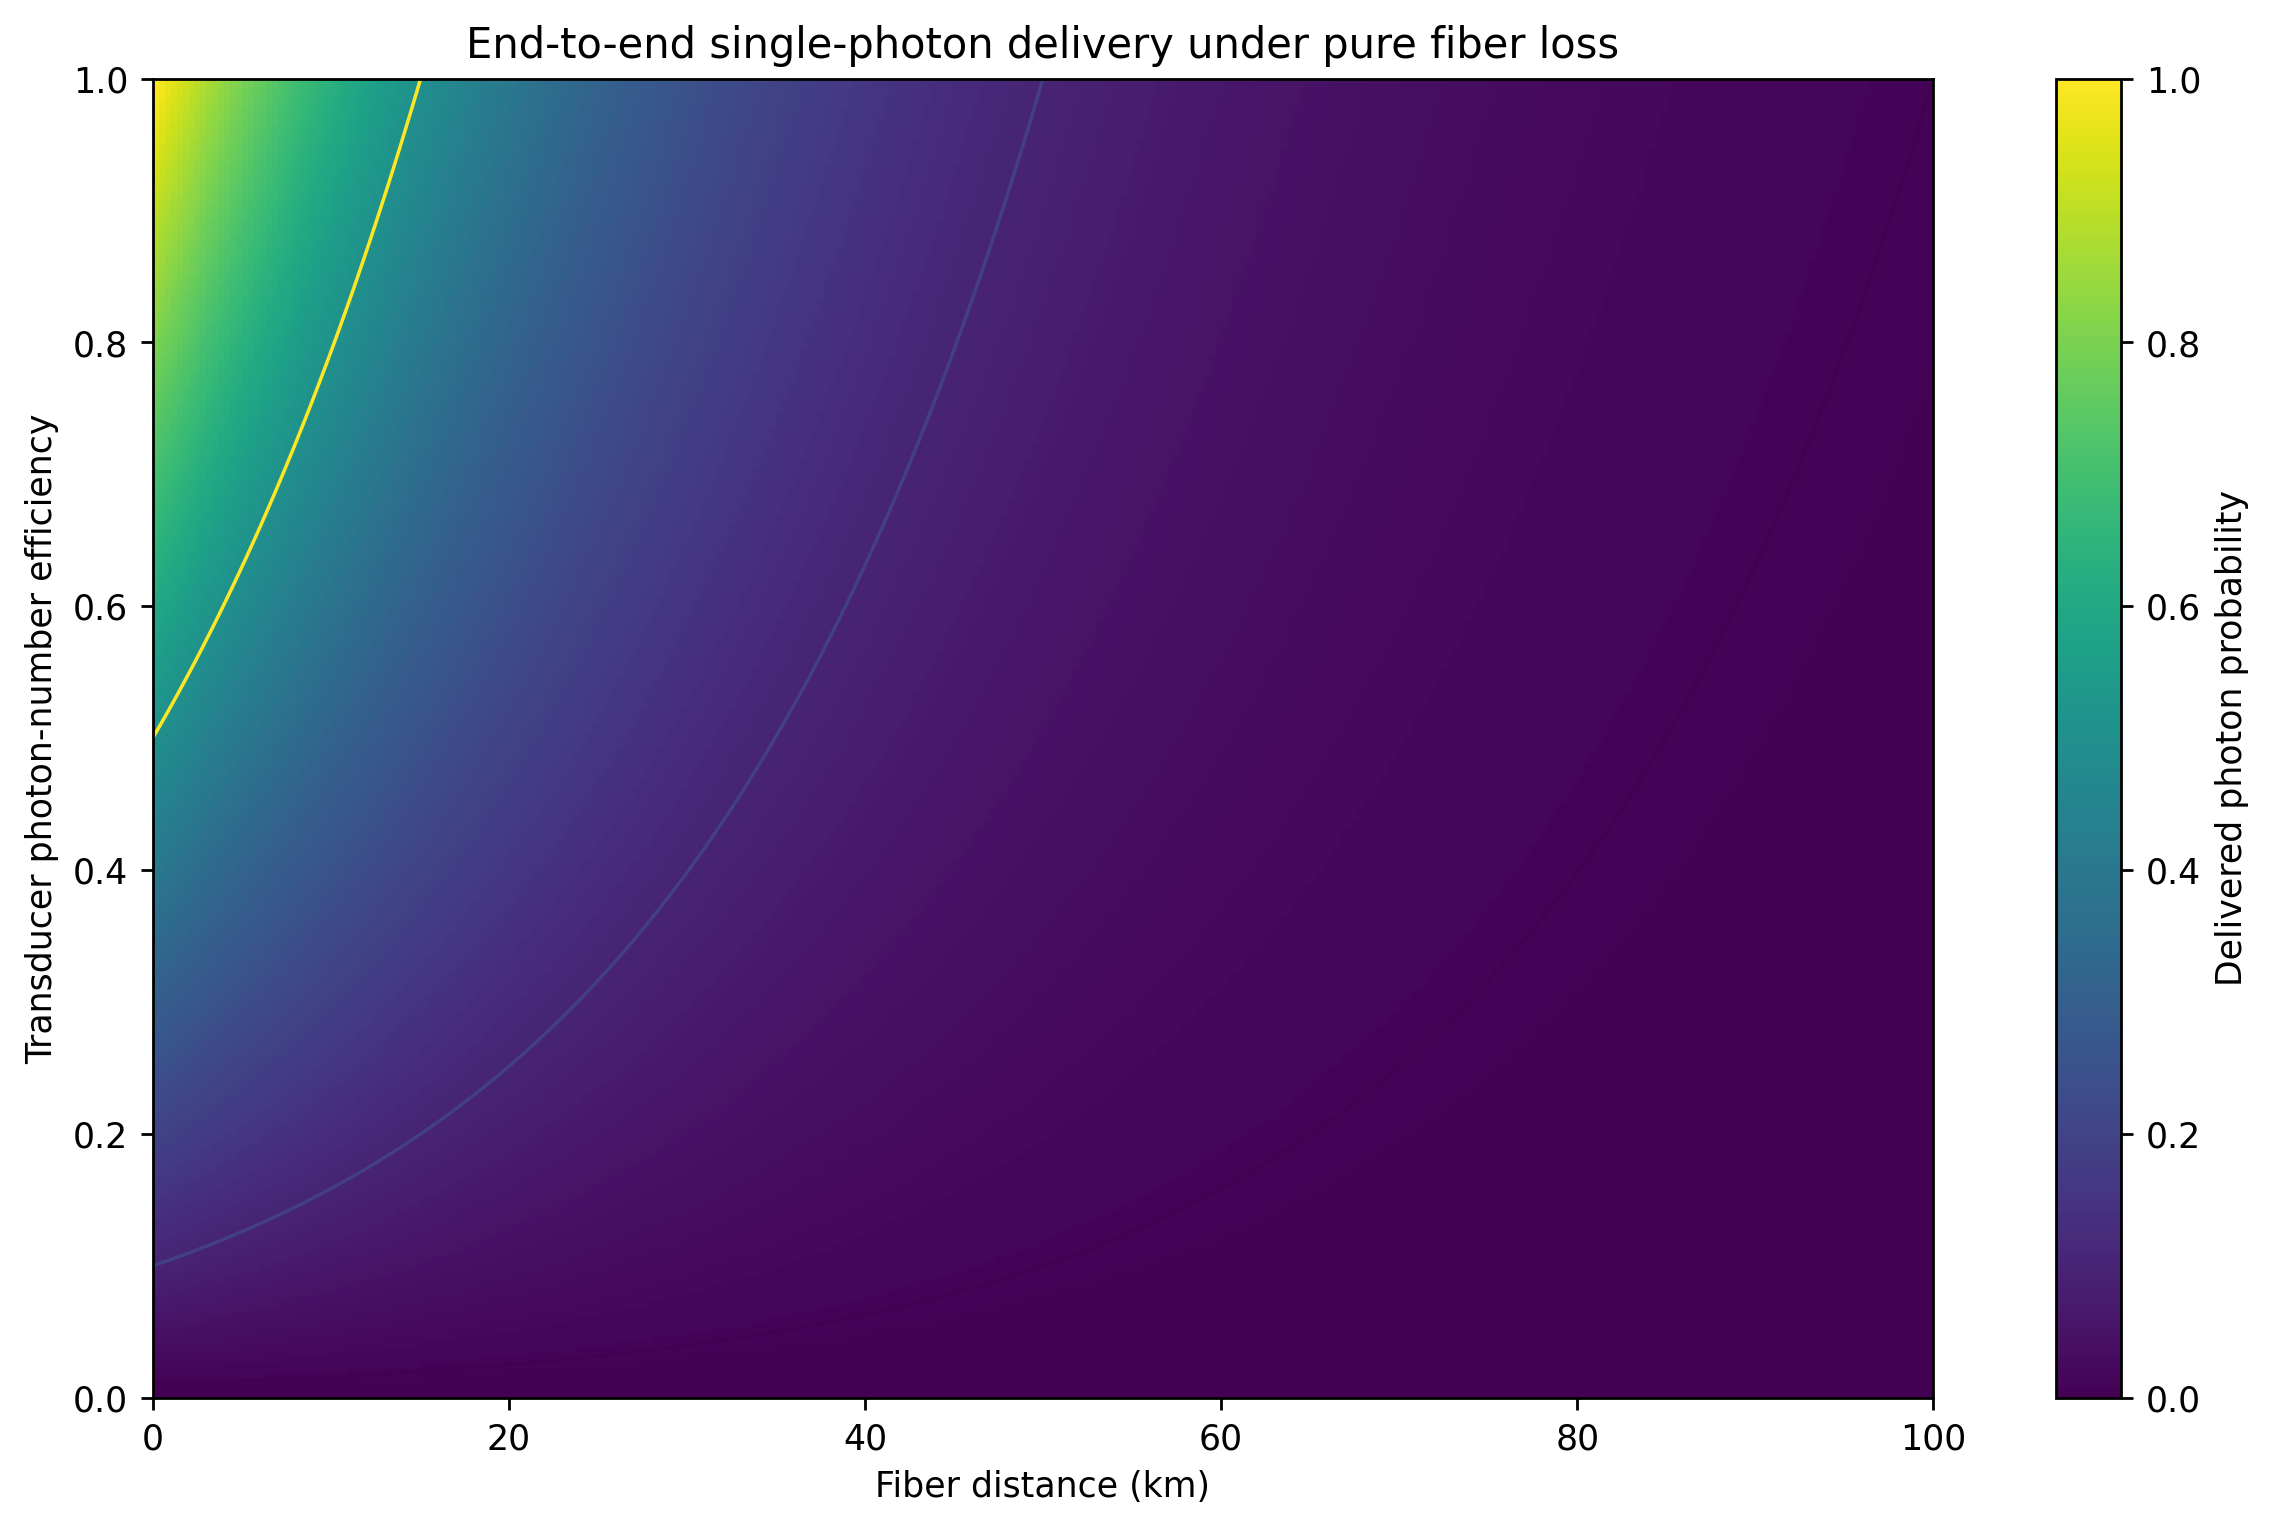

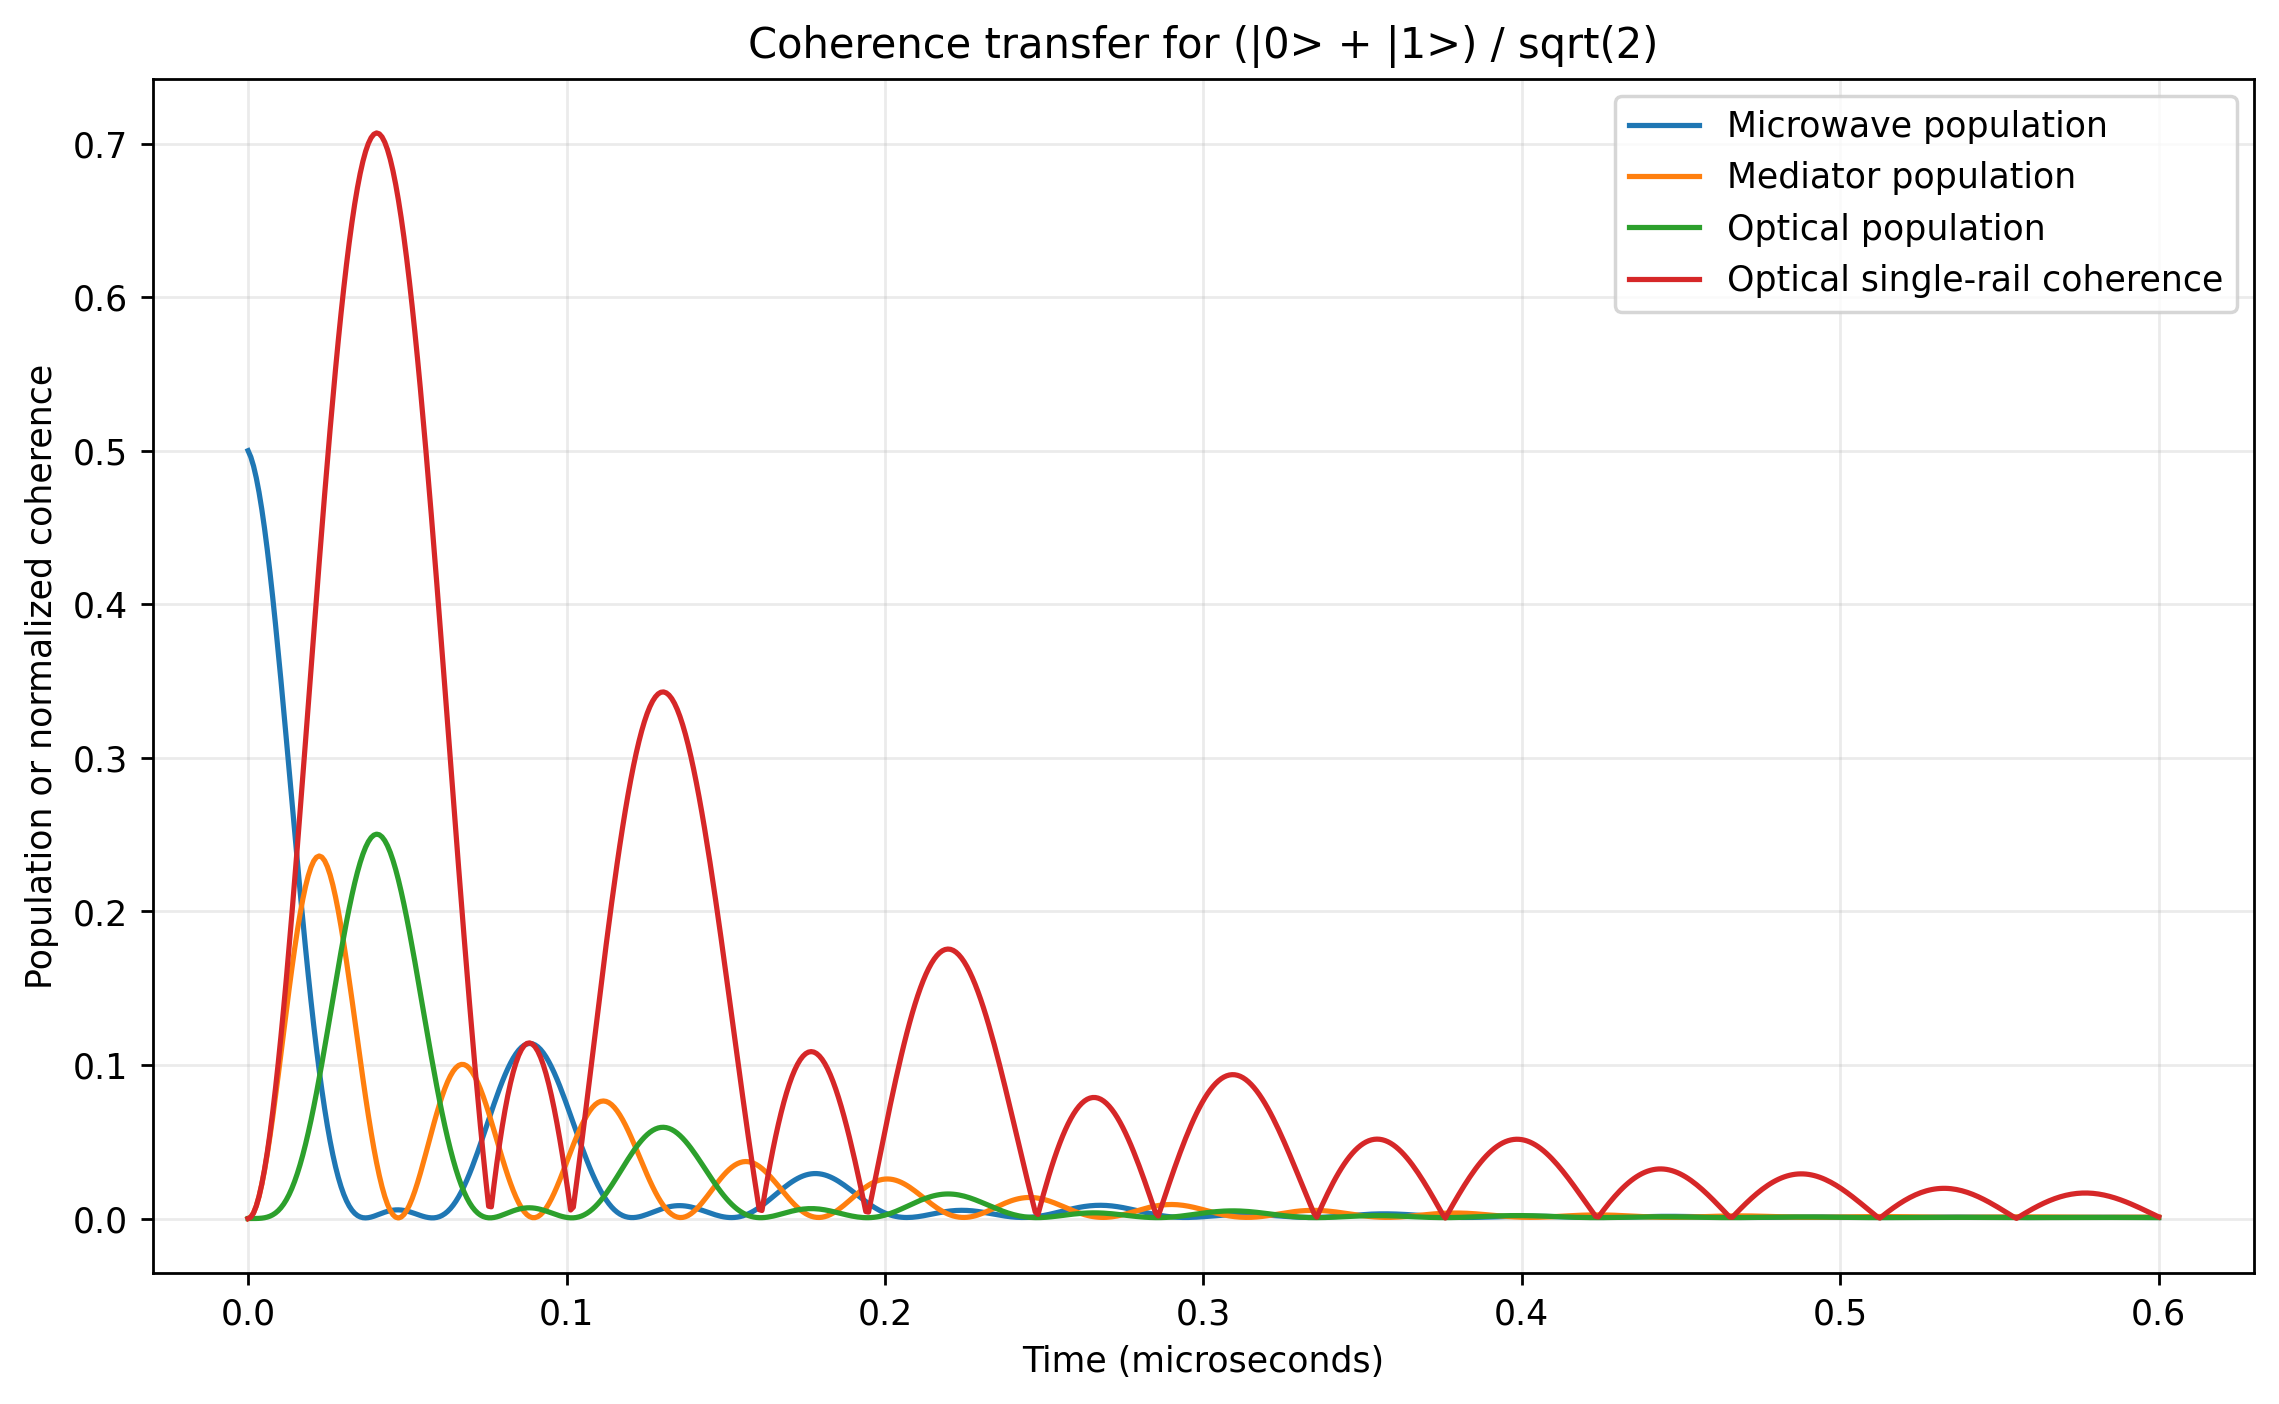

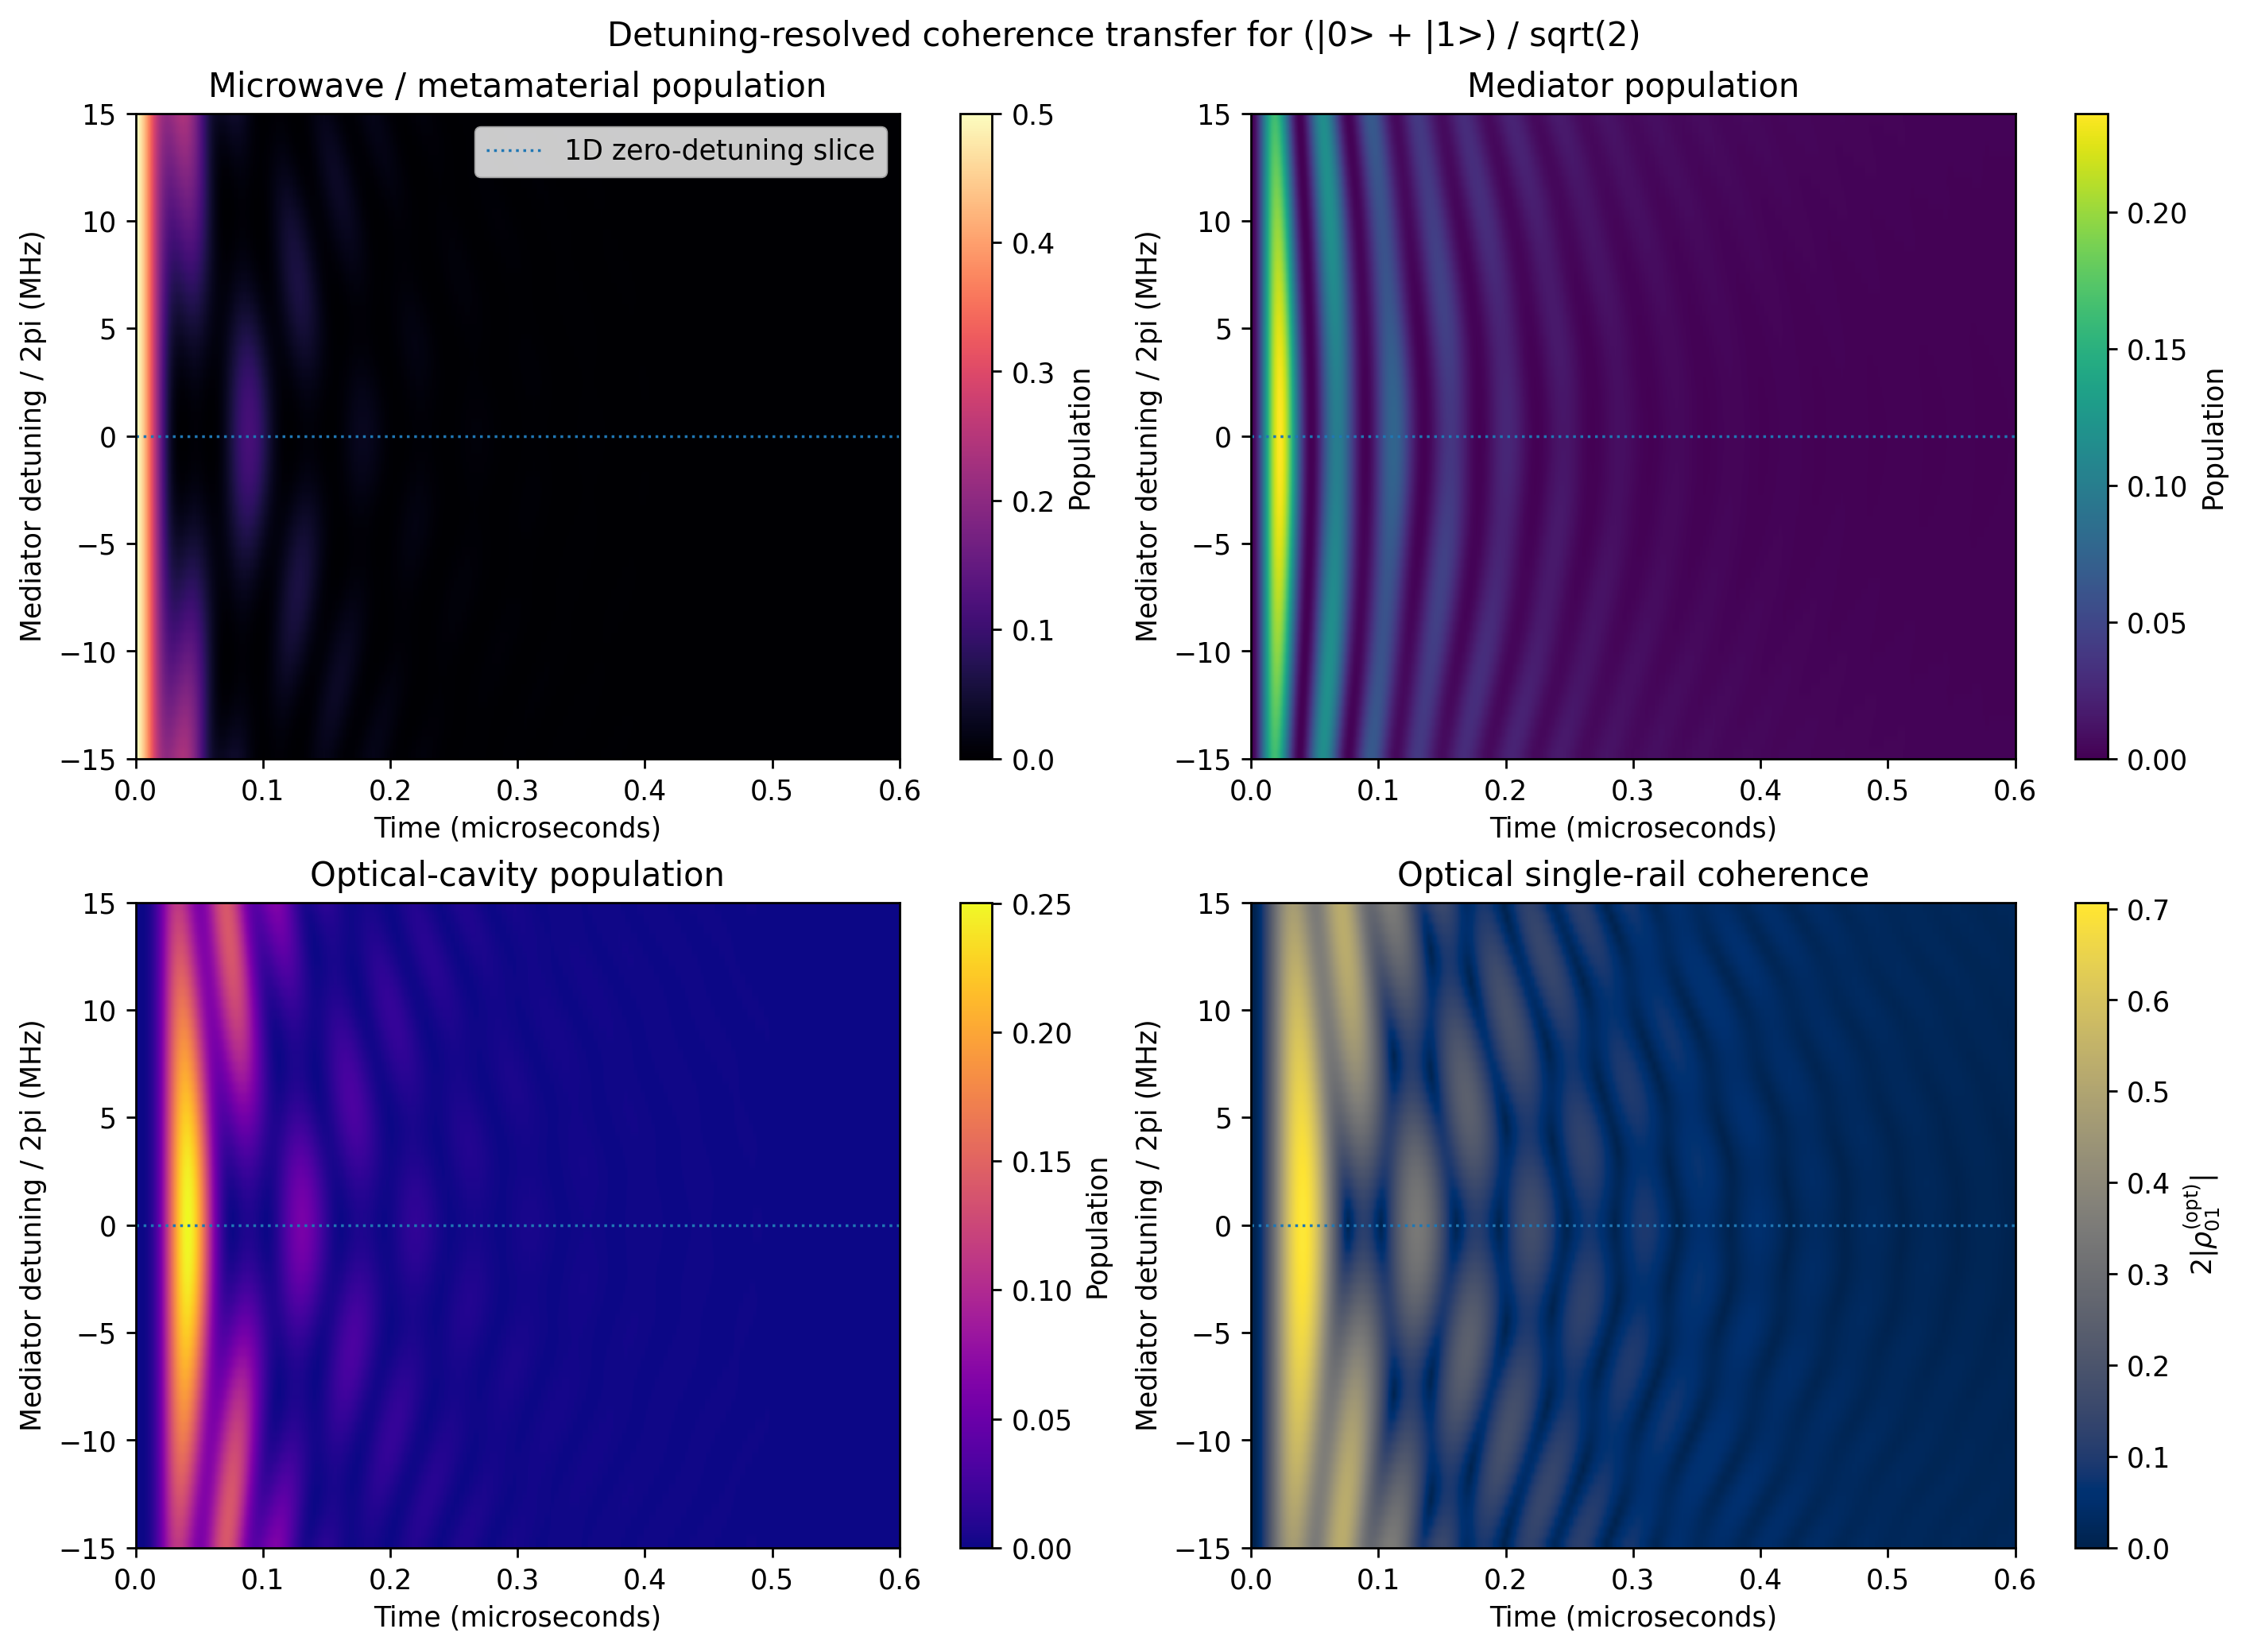

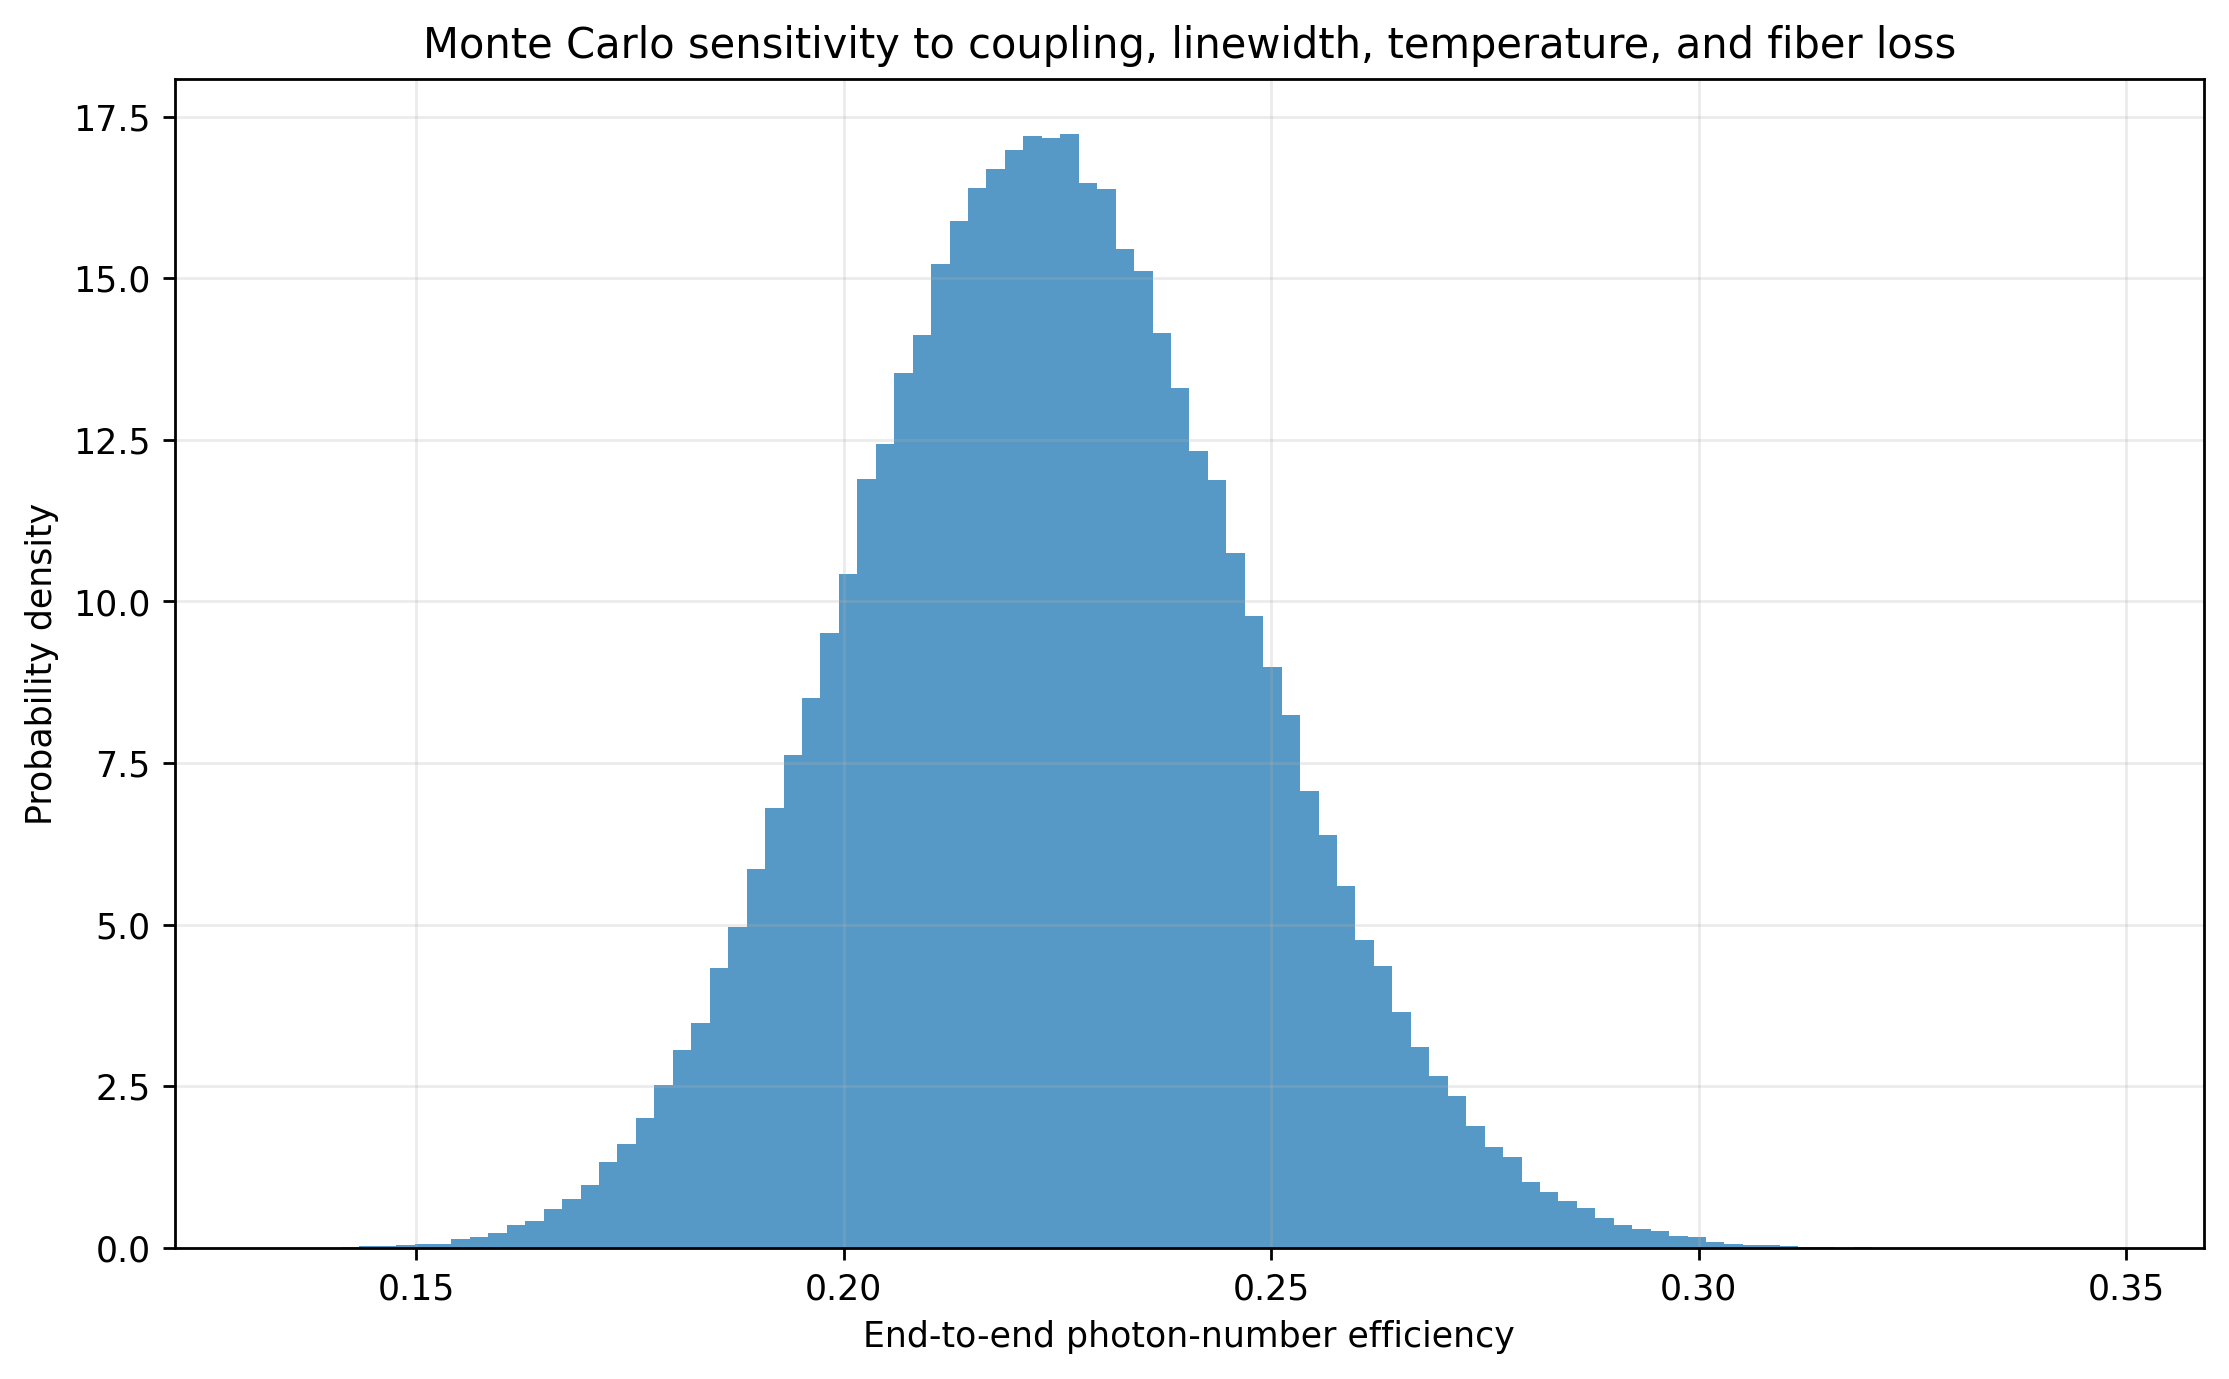

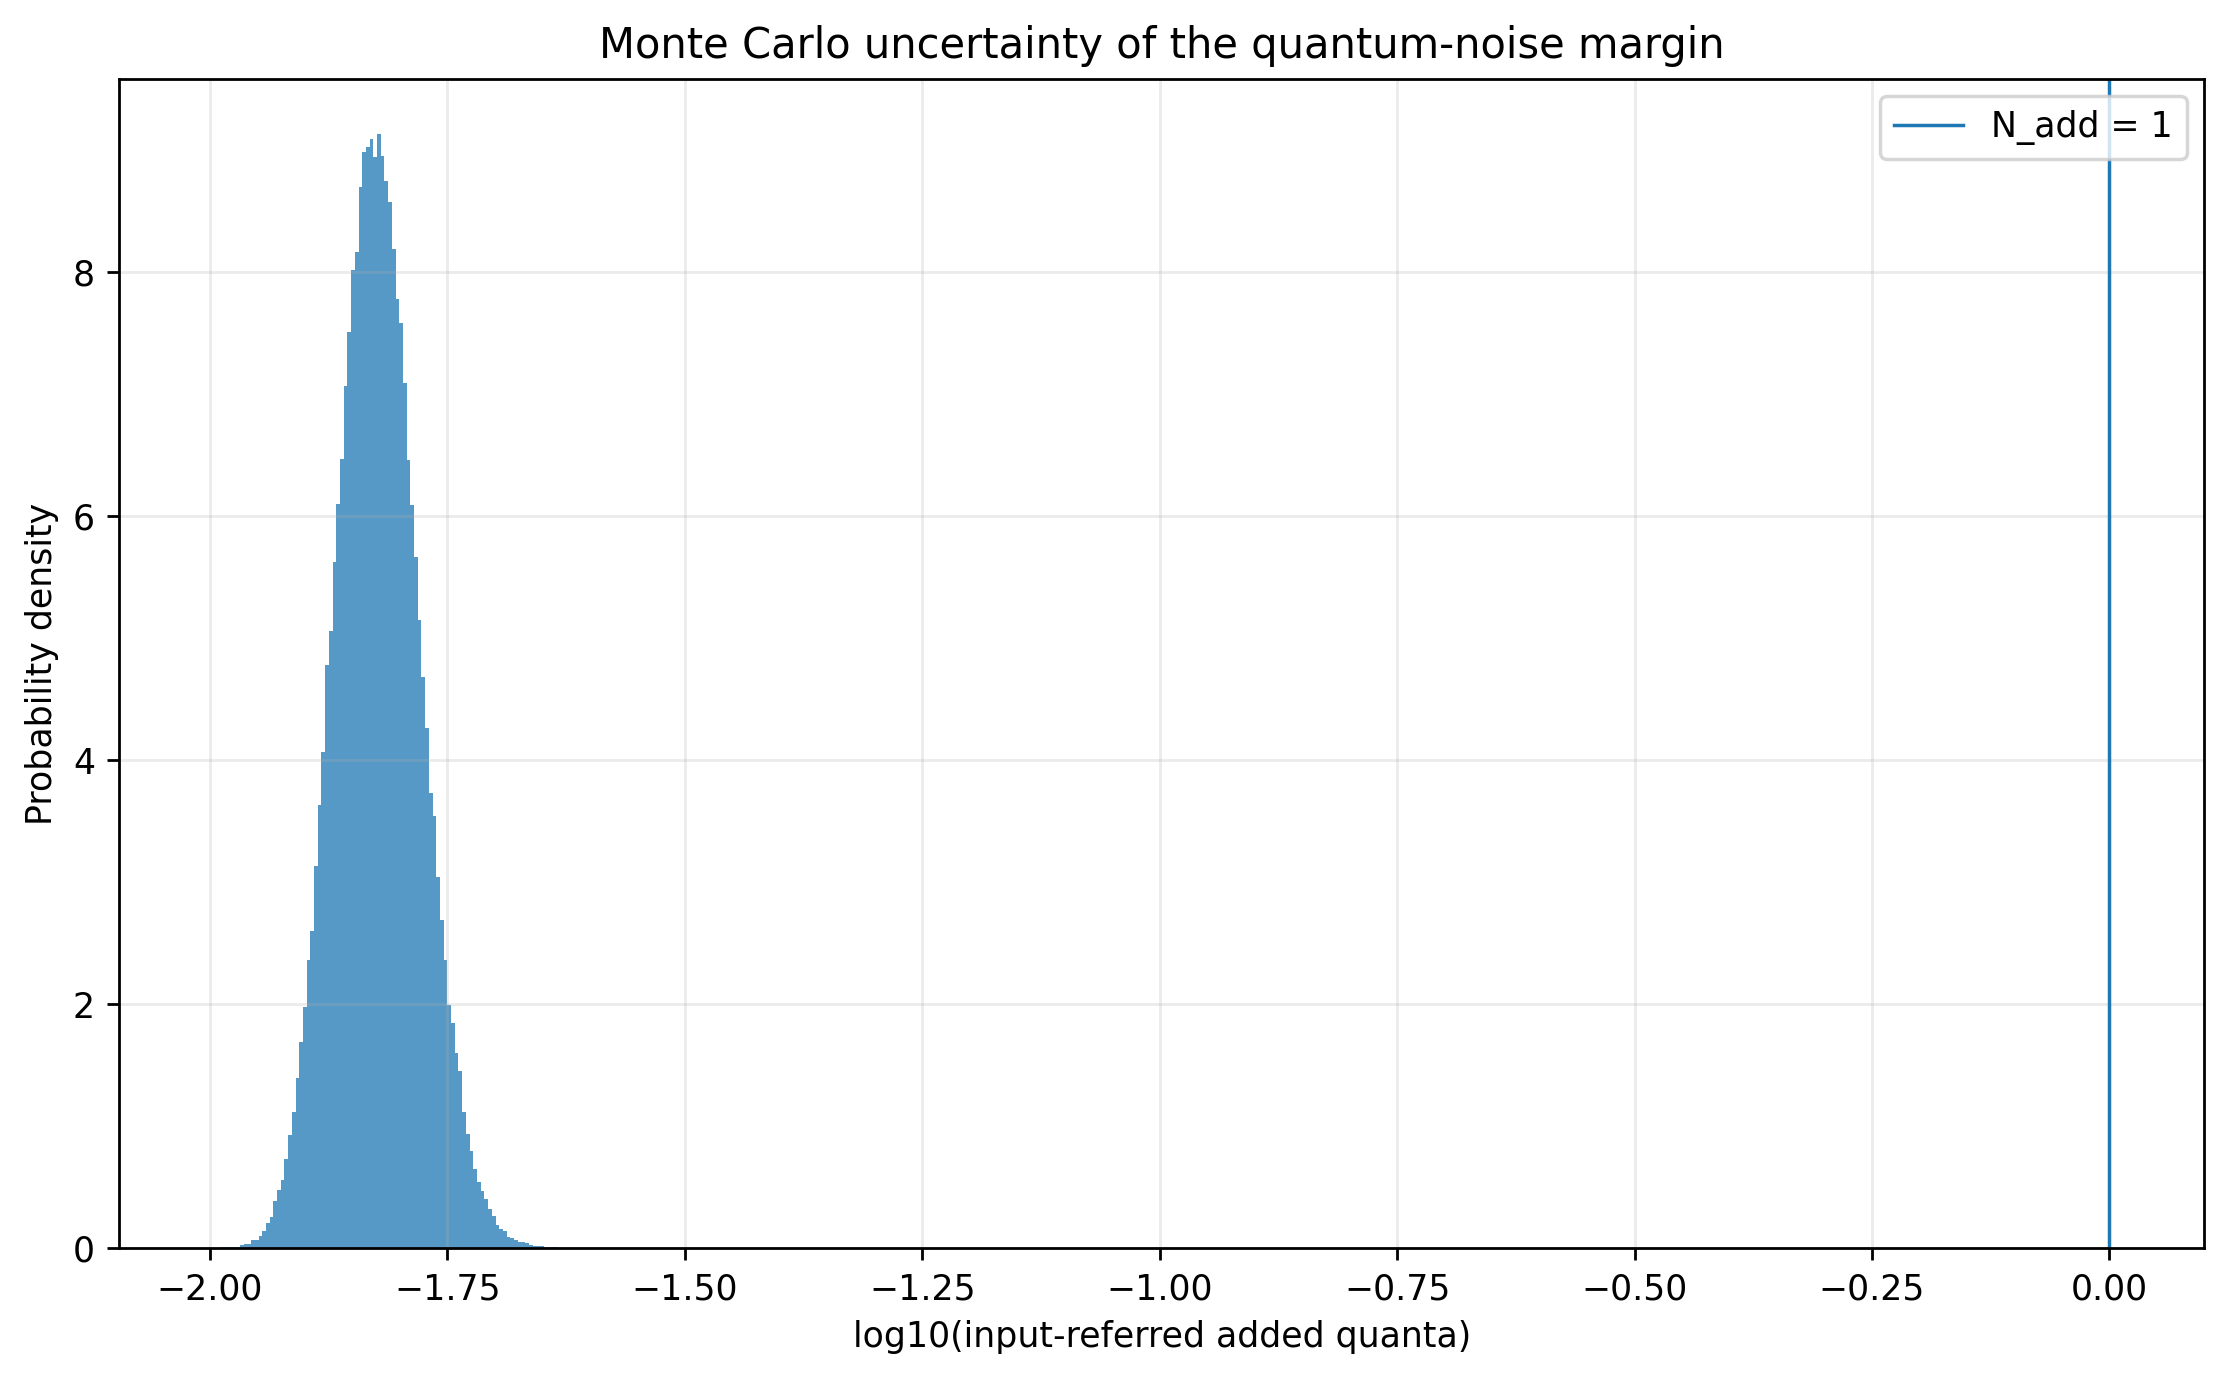

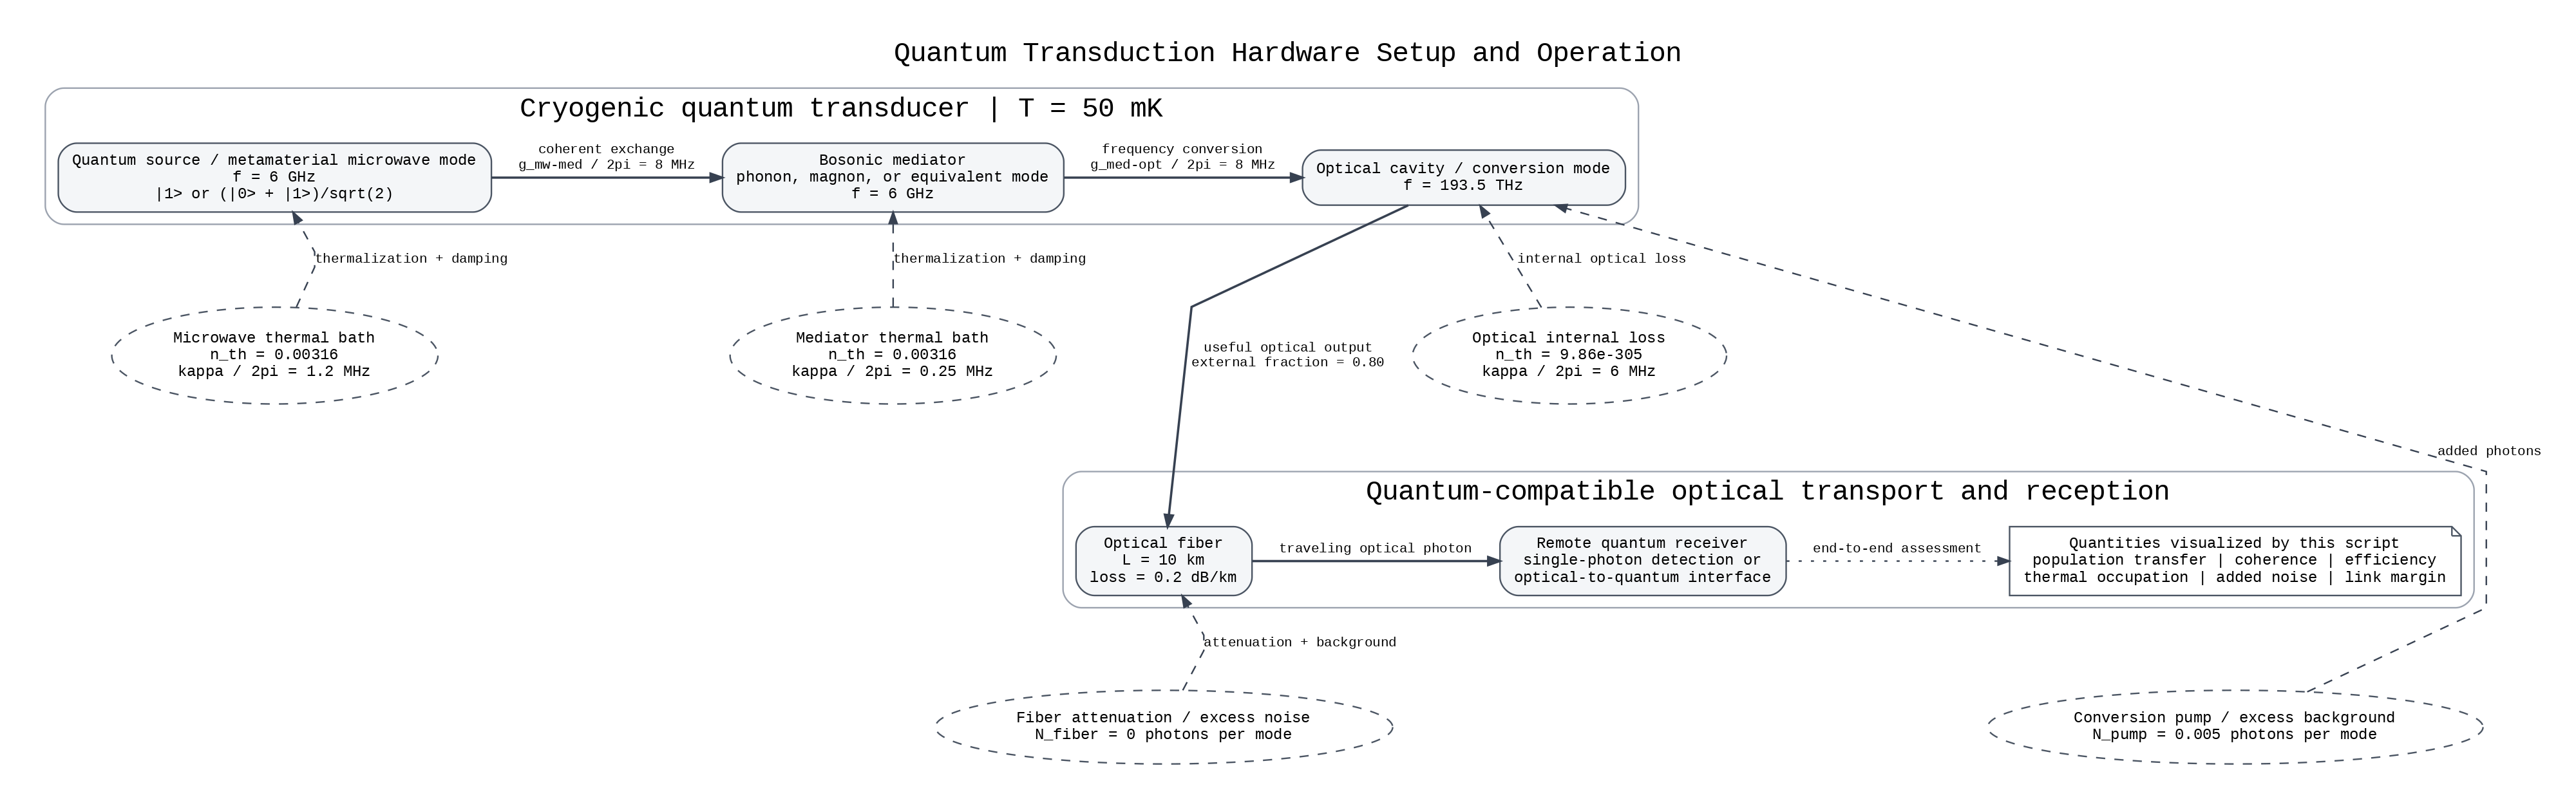


=== Quantum transduction checkpoints ===
Microwave thermal occupation: 0.00316395
Mediator thermal occupation: 0.00316395
Optical thermal occupation: 9.85968e-305
Fiber transmissivity at 10 km: 0.630957
Ideal external-coupling × fiber efficiency ceiling: 0.403813
Configured end-to-end benchmark: 0.500000
The configured 0.5 end-to-end reference is unreachable from external coupling and fiber loss alone.
Best swept end-to-end efficiency: 0.403564 at g1/2pi=11.089 MHz, g2/2pi=24.861 MHz
Added noise at that point: 0.00861071 quanta
Best joint benchmark margin: -0.931 dB
Monte Carlo median end-to-end efficiency: 0.223863
Monte Carlo probability of N_add < 1: 1.0000
Monte Carlo probability of N_add < 1 and eta > 0.5: 0.0000


In [10]:
"""Simulate staged quantum transduction and quantum-noise limits.

The script combines QuTiP Lindblad dynamics for time-domain single-excitation
transport with a CuPy-accelerated linear input-output sweep for large parameter
maps. The default architecture is a three-mode bosonic chain:

    microwave/metamaterial mode -> mediator -> optical cavity -> fiber.

The mediator can represent a phonon, magnon, or another approximately bosonic
intermediate mode in the linearized single-excitation regime.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

try:
    from qutip import basis, destroy, ket2dm, mesolve, qeye, tensor

    QUTIP_AVAILABLE = True
    QUTIP_IMPORT_ERROR: Exception | None = None
except Exception as exc:  # pragma: no cover - environment-dependent guard.
    basis = destroy = ket2dm = mesolve = qeye = tensor = None
    QUTIP_AVAILABLE = False
    QUTIP_IMPORT_ERROR = exc

try:
    import cupy as cp

    try:
        GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
    except Exception:
        GPU_AVAILABLE = False
except Exception:  # pragma: no cover - CPU fallback is intentional.
    cp = None
    GPU_AVAILABLE = False


try:
    from graphviz import Digraph

    GRAPHVIZ_AVAILABLE = True
    GRAPHVIZ_IMPORT_ERROR: Exception | None = None
except Exception as exc:  # pragma: no cover - environment-dependent guard.
    Digraph = None
    GRAPHVIZ_AVAILABLE = False
    GRAPHVIZ_IMPORT_ERROR = exc

try:
    from IPython.display import Image, display

    IPYTHON_DISPLAY_AVAILABLE = True
except Exception:  # pragma: no cover - plain Python fallback is intentional.
    Image = None
    display = None
    IPYTHON_DISPLAY_AVAILABLE = False


# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
PLOT_DPI = 250
SAVE_FIGURES = False
OUTPUT_DIR = Path("quantum_transduction_outputs")

# Graphviz hardware-diagram controls.
GRAPHVIZ_FORMAT = "png"
GRAPHVIZ_RANK_DIRECTION = "TB"
GRAPHVIZ_FONT = "DejaVu Sans"
GRAPHVIZ_WIDTH_IN = 16.0
GRAPHVIZ_HEIGHT_IN = 9.0
GRAPHVIZ_DPI = PLOT_DPI

# Device frequencies and temperature.
MW_FREQUENCY_GHZ = 6.0
MEDIATOR_FREQUENCY_GHZ = 6.0
OPTICAL_FREQUENCY_THz = 193.5
DEVICE_TEMPERATURE_K = 0.050

# QuTiP Hilbert-space truncation and dynamic grid.
FOCK_DIM = 3
TIME_MAX_US = 0.60
TIME_POINTS = 700
DETUNING_MIN_MHZ = -15.0
DETUNING_MAX_MHZ = 15.0
DETUNING_POINTS = 61

# Linearized beam-splitter interaction rates, quoted as g / (2 pi).
G_MW_MED_MHZ = 8.0
G_MED_OPT_MHZ = 8.0

# Energy-decay linewidths, quoted as kappa / (2 pi).
KAPPA_MW_MHZ = 1.2
KAPPA_MED_MHZ = 0.25
KAPPA_OPT_MHZ = 6.0

# Fraction of total cavity damping coupled to useful external ports.
MW_EXTERNAL_FRACTION = 0.80
OPT_EXTERNAL_FRACTION = 0.80

# Fiber controls. The loss is an adjustable illustrative telecom-band value.
FIBER_LENGTH_KM = 10.0
FIBER_LOSS_DB_PER_KM = 0.20
FIBER_EXCESS_NOISE_Q = 0.0

# Effective pump-induced output noise in photons per matched mode.
PUMP_EXCESS_OUTPUT_NOISE_Q = 0.005

# GPU parameter sweep.
SWEEP_G_MIN_MHZ = 0.10
SWEEP_G_MAX_MHZ = 25.0
SWEEP_POINTS = 180

# Thermal-occupation map.
THERMAL_FREQ_MIN_GHZ = 0.10
THERMAL_FREQ_MAX_GHZ = 3.0e5
THERMAL_TEMP_MIN_K = 0.005
THERMAL_TEMP_MAX_K = 300.0
THERMAL_MAP_POINTS = 320

# Fiber-delivery map.
FIBER_DISTANCE_MAX_KM = 100.0
FIBER_DISTANCE_POINTS = 300
TRANSDUCER_EFFICIENCY_POINTS = 260

# Monte Carlo uncertainty propagation.
RUN_MONTE_CARLO = True
MONTE_CARLO_SAMPLES = 200_000
RNG_SEED = 17
G_RELATIVE_SIGMA = 0.05
KAPPA_RELATIVE_SIGMA = 0.04
FIBER_LOSS_SIGMA_DB_PER_KM = 0.01
TEMPERATURE_SIGMA_K = 0.005

# Quantum-link benchmark controls.
# N_add < 1 marks the sub-single-photon added-noise regime.
ADDED_NOISE_BENCHMARK_Q = 1.0

# eta > 0.5 is retained as a pure-loss quantum-capacity reference boundary.
# It is a diagnostic reference rather than a universal transducer requirement.
ETA_TOTAL_BENCHMARK = 0.50

# Clip only the displayed joint margin so extreme low-efficiency regions do
# not suppress contrast near the physically relevant zero-dB boundary.
BENCHMARK_MARGIN_DISPLAY_DB = 15.0

# Numerical controls.
EPSILON = 1.0e-12
ODE_RTOL = 1.0e-8
ODE_ATOL = 1.0e-10

# Exact SI constants. These values are exact under the current SI definition.
H_PLANCK = 6.626_070_15e-34
K_B = 1.380_649e-23

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI


@dataclass(frozen=True)
class Rates:
    """Store angular-frequency decay and coupling rates in inverse microseconds."""

    g_mw_med: float
    g_med_opt: float
    kappa_mw: float
    kappa_med: float
    kappa_opt: float
    kappa_mw_ext: float
    kappa_mw_int: float
    kappa_opt_ext: float
    kappa_opt_int: float


@dataclass(frozen=True)
class ThermalOccupations:
    """Store thermal occupations for microwave, mediator, and optical modes."""

    microwave: float
    mediator: float
    optical: float


def validate_controls() -> None:
    """Validate user-adjustable simulation controls before allocating arrays."""
    positive_values = {
        "FOCK_DIM": FOCK_DIM,
        "TIME_MAX_US": TIME_MAX_US,
        "TIME_POINTS": TIME_POINTS,
        "DETUNING_POINTS": DETUNING_POINTS,
        "SWEEP_POINTS": SWEEP_POINTS,
        "THERMAL_MAP_POINTS": THERMAL_MAP_POINTS,
        "FIBER_DISTANCE_POINTS": FIBER_DISTANCE_POINTS,
        "TRANSDUCER_EFFICIENCY_POINTS": TRANSDUCER_EFFICIENCY_POINTS,
        "MONTE_CARLO_SAMPLES": MONTE_CARLO_SAMPLES,
    }
    for name, value in positive_values.items():
        if value <= 0:
            raise ValueError(f"{name} must be positive; received {value!r}.")

    if FOCK_DIM < 2:
        raise ValueError("FOCK_DIM must be at least 2 for a single-photon state.")

    fractions = {
        "MW_EXTERNAL_FRACTION": MW_EXTERNAL_FRACTION,
        "OPT_EXTERNAL_FRACTION": OPT_EXTERNAL_FRACTION,
    }
    for name, value in fractions.items():
        if not 0.0 <= value <= 1.0:
            raise ValueError(f"{name} must lie in [0, 1]; received {value!r}.")

    if DEVICE_TEMPERATURE_K <= 0.0:
        raise ValueError("DEVICE_TEMPERATURE_K must be greater than zero.")
    if FIBER_LENGTH_KM < 0.0 or FIBER_LOSS_DB_PER_KM < 0.0:
        raise ValueError("Fiber length and loss must be nonnegative.")


def require_qutip() -> None:
    """Raise an actionable error if QuTiP could not be imported."""
    if QUTIP_AVAILABLE:
        return

    message = (
        "QuTiP could not be imported. In Google Colab, restart the runtime if "
        "the previous notebook upgraded NumPy/SciPy in place, then run: "
        "!uv pip install -q 'qutip==5.2.3' 'cupy-cuda12x>=13,<14'"
    )
    if QUTIP_IMPORT_ERROR is not None:
        message += f"\nOriginal import error: {QUTIP_IMPORT_ERROR!r}"
    raise ImportError(message) from QUTIP_IMPORT_ERROR


def require_graphviz() -> None:
    """Raise an actionable error if the Graphviz Python package is unavailable."""
    if GRAPHVIZ_AVAILABLE:
        return

    message = (
        "Graphviz could not be imported. Add the Python package to the Colab "
        "installation cell before running the hardware-diagram section."
    )
    if GRAPHVIZ_IMPORT_ERROR is not None:
        message += f"\nOriginal import error: {GRAPHVIZ_IMPORT_ERROR!r}"
    raise ImportError(message) from GRAPHVIZ_IMPORT_ERROR


def rate_from_mhz(value_mhz: float) -> float:
    """Convert a rate quoted as rate/(2 pi) in MHz to rad per microsecond."""
    return 2.0 * np.pi * value_mhz


def thermal_occupation(frequency_hz: Any, temperature_k: Any, xp=np) -> Any:
    """Return the Bose-Einstein mean occupation of a bosonic mode.

    Args:
        frequency_hz: Mode frequency in hertz.
        temperature_k: Bath temperature in kelvin.
        xp: NumPy-compatible array module, either NumPy or CuPy.

    Returns:
        Mean thermal occupation number with broadcast-compatible shape.
    """
    frequency = xp.asarray(frequency_hz, dtype=xp.float64)
    temperature = xp.asarray(temperature_k, dtype=xp.float64)

    if xp is np and np.any(temperature <= 0.0):
        raise ValueError("All temperatures must be greater than zero.")

    safe_temperature = xp.maximum(temperature, EPSILON)
    exponent = H_PLANCK * frequency / (K_B * safe_temperature)
    exponent = xp.clip(exponent, 1.0e-12, 700.0)
    return 1.0 / xp.expm1(exponent)


def fiber_transmissivity(length_km: Any, loss_db_per_km: Any, xp=np) -> Any:
    """Return photon-number transmissivity for a lossy optical fiber."""
    return xp.power(10.0, -(loss_db_per_km * length_km) / 10.0)


def ideal_link_efficiency_ceiling() -> float:
    """Return the external-coupling and fiber-loss efficiency ceiling.

    The estimate assumes ideal internal mode conversion and therefore excludes
    mediator dissipation. It is an upper bound set by the configured microwave
    port coupling, optical port coupling, and fiber attenuation.

    Returns:
        Ideal end-to-end photon-number efficiency ceiling.
    """
    eta_fiber = float(
        fiber_transmissivity(
            FIBER_LENGTH_KM,
            FIBER_LOSS_DB_PER_KM,
        )
    )
    return MW_EXTERNAL_FRACTION * OPT_EXTERNAL_FRACTION * eta_fiber


def cumulative_trapezoid_axis1(values: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Integrate a two-dimensional array cumulatively along axis 1.

    This local implementation replaces ``scipy.integrate.cumulative_trapezoid``
    and prevents the main script from importing SciPy directly.

    Args:
        values: Array with shape ``(n_curves, n_samples)``.
        x: Monotonic one-dimensional coordinate array with ``n_samples`` values.

    Returns:
        Cumulative trapezoidal integral with the same shape as ``values`` and
        an initial zero in each row.
    """
    values = np.asarray(values, dtype=float)
    x = np.asarray(x, dtype=float)

    if values.ndim != 2:
        raise ValueError("values must be a two-dimensional array.")
    if x.ndim != 1 or x.size != values.shape[1]:
        raise ValueError("x must be one-dimensional and match values.shape[1].")
    if x.size < 2:
        return np.zeros_like(values)

    dx = np.diff(x)[None, :]
    increments = 0.5 * (values[:, 1:] + values[:, :-1]) * dx
    integrated = np.cumsum(increments, axis=1)
    return np.concatenate(
        [np.zeros((values.shape[0], 1), dtype=float), integrated],
        axis=1,
    )


def build_rates() -> Rates:
    """Create all model rates from the control knobs."""
    kappa_mw = rate_from_mhz(KAPPA_MW_MHZ)
    kappa_opt = rate_from_mhz(KAPPA_OPT_MHZ)
    return Rates(
        g_mw_med=rate_from_mhz(G_MW_MED_MHZ),
        g_med_opt=rate_from_mhz(G_MED_OPT_MHZ),
        kappa_mw=kappa_mw,
        kappa_med=rate_from_mhz(KAPPA_MED_MHZ),
        kappa_opt=kappa_opt,
        kappa_mw_ext=MW_EXTERNAL_FRACTION * kappa_mw,
        kappa_mw_int=(1.0 - MW_EXTERNAL_FRACTION) * kappa_mw,
        kappa_opt_ext=OPT_EXTERNAL_FRACTION * kappa_opt,
        kappa_opt_int=(1.0 - OPT_EXTERNAL_FRACTION) * kappa_opt,
    )


def build_thermal_occupations() -> ThermalOccupations:
    """Compute bath occupations at the configured device temperature."""
    n_mw = float(
        thermal_occupation(MW_FREQUENCY_GHZ * 1.0e9, DEVICE_TEMPERATURE_K)
    )
    n_med = float(
        thermal_occupation(
            MEDIATOR_FREQUENCY_GHZ * 1.0e9,
            DEVICE_TEMPERATURE_K,
        )
    )
    n_opt = float(
        thermal_occupation(OPTICAL_FREQUENCY_THz * 1.0e12, DEVICE_TEMPERATURE_K)
    )
    return ThermalOccupations(n_mw, n_med, n_opt)


def build_qutip_operators() -> dict[str, Any]:
    """Construct annihilation, number, and optical coherence operators."""
    require_qutip()
    ident = qeye(FOCK_DIM)
    destroy_local = destroy(FOCK_DIM)

    a_mw = tensor(destroy_local, ident, ident)
    a_med = tensor(ident, destroy_local, ident)
    a_opt = tensor(ident, ident, destroy_local)

    n_mw = a_mw.dag() * a_mw
    n_med = a_med.dag() * a_med
    n_opt = a_opt.dag() * a_opt

    optical_01 = tensor(
        ident,
        ident,
        basis(FOCK_DIM, 0) * basis(FOCK_DIM, 1).dag(),
    )

    return {
        "a_mw": a_mw,
        "a_med": a_med,
        "a_opt": a_opt,
        "n_mw": n_mw,
        "n_med": n_med,
        "n_opt": n_opt,
        "optical_01": optical_01,
    }


def thermal_collapse_operators(
    operators: dict[str, Any],
    rates: Rates,
    occupations: ThermalOccupations,
) -> list[Any]:
    """Build Lindblad operators for damping into thermal reservoirs."""
    collapse_ops = []
    mode_data = (
        (operators["a_mw"], rates.kappa_mw, occupations.microwave),
        (operators["a_med"], rates.kappa_med, occupations.mediator),
        (operators["a_opt"], rates.kappa_opt, occupations.optical),
    )

    for annihilation, kappa, n_th in mode_data:
        collapse_ops.append(np.sqrt(kappa * (n_th + 1.0)) * annihilation)
        if n_th > 1.0e-14:
            collapse_ops.append(np.sqrt(kappa * n_th) * annihilation.dag())

    return collapse_ops


def transduction_hamiltonian(
    detuning_mhz: float,
    operators: dict[str, Any],
    rates: Rates,
) -> Any:
    """Construct the linearized three-mode beam-splitter Hamiltonian."""
    delta = rate_from_mhz(detuning_mhz)
    a_mw = operators["a_mw"]
    a_med = operators["a_med"]
    a_opt = operators["a_opt"]

    return (
        delta * operators["n_med"]
        + rates.g_mw_med * (a_mw.dag() * a_med + a_mw * a_med.dag())
        + rates.g_med_opt * (a_med.dag() * a_opt + a_med * a_opt.dag())
    )


def initial_density_matrix(signal: bool) -> Any:
    """Create a one-photon source state or a full vacuum state."""
    require_qutip()
    mw_index = 1 if signal else 0
    ket = tensor(
        basis(FOCK_DIM, mw_index),
        basis(FOCK_DIM, 0),
        basis(FOCK_DIM, 0),
    )
    return ket2dm(ket)


def solver_options() -> dict[str, Any]:
    """Return QuTiP solver settings used by the deterministic calculations."""
    return {
        "store_states": False,
        "progress_bar": False,
        "rtol": ODE_RTOL,
        "atol": ODE_ATOL,
    }


def simulate_dynamic_heatmaps(
    rates: Rates,
    occupations: ThermalOccupations,
) -> dict[str, np.ndarray]:
    """Run QuTiP dynamics over detuning and time for signal and noise states."""
    require_qutip()
    operators = build_qutip_operators()
    collapse_ops = thermal_collapse_operators(operators, rates, occupations)

    times = np.linspace(0.0, TIME_MAX_US, TIME_POINTS)
    detunings = np.linspace(
        DETUNING_MIN_MHZ,
        DETUNING_MAX_MHZ,
        DETUNING_POINTS,
    )

    shape = (detunings.size, times.size)
    mw_signal = np.zeros(shape)
    med_signal = np.zeros(shape)
    opt_signal = np.zeros(shape)
    opt_noise = np.zeros(shape)

    expectations = [
        operators["n_mw"],
        operators["n_med"],
        operators["n_opt"],
    ]

    rho_signal = initial_density_matrix(signal=True)
    rho_noise = initial_density_matrix(signal=False)

    for index, detuning in enumerate(detunings):
        hamiltonian = transduction_hamiltonian(detuning, operators, rates)

        signal_result = mesolve(
            hamiltonian,
            rho_signal,
            times,
            c_ops=collapse_ops,
            e_ops=expectations,
            options=solver_options(),
        )
        noise_result = mesolve(
            hamiltonian,
            rho_noise,
            times,
            c_ops=collapse_ops,
            e_ops=expectations,
            options=solver_options(),
        )

        signal_expect = np.real(np.asarray(signal_result.expect))
        noise_expect = np.real(np.asarray(noise_result.expect))

        mw_signal[index] = np.clip(
            signal_expect[0] - noise_expect[0],
            0.0,
            None,
        )
        med_signal[index] = np.clip(
            signal_expect[1] - noise_expect[1],
            0.0,
            None,
        )
        opt_signal[index] = np.clip(
            signal_expect[2] - noise_expect[2],
            0.0,
            None,
        )
        opt_noise[index] = np.clip(noise_expect[2], 0.0, None)

    optical_signal_flux = rates.kappa_opt_ext * opt_signal
    optical_noise_flux = rates.kappa_opt_ext * opt_noise

    emitted_signal = cumulative_trapezoid_axis1(optical_signal_flux, times)
    emitted_noise = cumulative_trapezoid_axis1(optical_noise_flux, times)

    eta_fiber = float(
        fiber_transmissivity(FIBER_LENGTH_KM, FIBER_LOSS_DB_PER_KM)
    )
    fiber_signal = eta_fiber * emitted_signal

    if times[-1] > 0.0:
        fiber_noise_fraction = times / times[-1]
    else:
        fiber_noise_fraction = np.zeros_like(times)

    fiber_noise = (
        eta_fiber * emitted_noise
        + FIBER_EXCESS_NOISE_Q * fiber_noise_fraction[None, :]
    )
    input_referred_noise = fiber_noise / np.maximum(fiber_signal, EPSILON)

    return {
        "times_us": times,
        "detunings_mhz": detunings,
        "mw_signal": mw_signal,
        "med_signal": med_signal,
        "opt_signal": opt_signal,
        "emitted_signal": emitted_signal,
        "fiber_signal": fiber_signal,
        "input_referred_noise": input_referred_noise,
    }


def simulate_coherence_trace(
    rates: Rates,
    occupations: ThermalOccupations,
) -> dict[str, np.ndarray]:
    """Compute 1D and 2D coherence-transfer observables over detuning.

    The source is prepared in the single-rail superposition

        (|0> + |1>) / sqrt(2),

    and propagated for every mediator detuning in the same grid used by the
    staged population heat maps. The returned 1D traces are the row nearest
    zero detuning, so every line in ``plot_coherence_trace`` has a directly
    corresponding panel in ``plot_coherence_heatmaps``.

    Args:
        rates: Coupling and dissipation rates in inverse microseconds.
        occupations: Thermal occupations of the three reservoir modes.

    Returns:
        Dictionary containing time and detuning axes, four two-dimensional
        observable maps, and their zero-detuning one-dimensional slices.
    """
    require_qutip()
    operators = build_qutip_operators()
    collapse_ops = thermal_collapse_operators(
        operators,
        rates,
        occupations,
    )
    times = np.linspace(0.0, TIME_MAX_US, TIME_POINTS)
    detunings = np.linspace(
        DETUNING_MIN_MHZ,
        DETUNING_MAX_MHZ,
        DETUNING_POINTS,
    )

    source_superposition = (
        basis(FOCK_DIM, 0) + basis(FOCK_DIM, 1)
    ).unit()
    psi0 = tensor(
        source_superposition,
        basis(FOCK_DIM, 0),
        basis(FOCK_DIM, 0),
    )
    rho0 = ket2dm(psi0)

    e_ops = [
        operators["n_mw"],
        operators["n_med"],
        operators["n_opt"],
        operators["optical_01"],
    ]

    shape = (detunings.size, times.size)
    mw_population_map = np.zeros(shape, dtype=float)
    med_population_map = np.zeros(shape, dtype=float)
    opt_population_map = np.zeros(shape, dtype=float)
    opt_coherence_map = np.zeros(shape, dtype=float)

    for index, detuning in enumerate(detunings):
        hamiltonian = transduction_hamiltonian(
            detuning,
            operators,
            rates,
        )
        result = mesolve(
            hamiltonian,
            rho0,
            times,
            c_ops=collapse_ops,
            e_ops=e_ops,
            options=solver_options(),
        )

        mw_population_map[index] = np.clip(
            np.real(result.expect[0]),
            0.0,
            None,
        )
        med_population_map[index] = np.clip(
            np.real(result.expect[1]),
            0.0,
            None,
        )
        opt_population_map[index] = np.clip(
            np.real(result.expect[2]),
            0.0,
            None,
        )
        opt_coherence_map[index] = np.clip(
            2.0 * np.abs(result.expect[3]),
            0.0,
            1.0,
        )

    zero_index = int(np.argmin(np.abs(detunings)))

    return {
        "times_us": times,
        "detunings_mhz": detunings,
        "mw_population": mw_population_map[zero_index],
        "med_population": med_population_map[zero_index],
        "opt_population": opt_population_map[zero_index],
        "opt_coherence": opt_coherence_map[zero_index],
        "mw_population_map": mw_population_map,
        "med_population_map": med_population_map,
        "opt_population_map": opt_population_map,
        "opt_coherence_map": opt_coherence_map,
    }


def array_module() -> Any:
    """Return CuPy on a usable CUDA device, otherwise NumPy."""
    return cp if GPU_AVAILABLE else np


def to_numpy(array: Any) -> np.ndarray:
    """Move an array to host memory if it is a CuPy array."""
    if GPU_AVAILABLE and cp is not None and isinstance(array, cp.ndarray):
        return cp.asnumpy(array)
    return np.asarray(array)


def linear_response_parameter_sweep(
    rates: Rates,
    occupations: ThermalOccupations,
) -> dict[str, np.ndarray]:
    """Compute steady-state conversion and added-noise maps on GPU or CPU.

    The calculation solves the resonant linear three-mode input-output
    equations. The right-hand-side columns represent the microwave signal,
    microwave internal bath, mediator bath, and optical internal bath.
    """
    xp = array_module()
    g_axis_mhz = xp.linspace(
        SWEEP_G_MIN_MHZ,
        SWEEP_G_MAX_MHZ,
        SWEEP_POINTS,
        dtype=xp.float64,
    )
    g_mw_med_mhz, g_med_opt_mhz = xp.meshgrid(
        g_axis_mhz,
        g_axis_mhz,
        indexing="xy",
    )
    g_mw_med = 2.0 * xp.pi * g_mw_med_mhz
    g_med_opt = 2.0 * xp.pi * g_med_opt_mhz

    grid_shape = g_mw_med.shape
    matrix = xp.zeros(grid_shape + (3, 3), dtype=xp.complex128)

    matrix[..., 0, 0] = 0.5 * rates.kappa_mw
    matrix[..., 1, 1] = 0.5 * rates.kappa_med
    matrix[..., 2, 2] = 0.5 * rates.kappa_opt
    matrix[..., 0, 1] = 1j * g_mw_med
    matrix[..., 1, 0] = 1j * g_mw_med
    matrix[..., 1, 2] = 1j * g_med_opt
    matrix[..., 2, 1] = 1j * g_med_opt

    rhs = xp.zeros(grid_shape + (3, 4), dtype=xp.complex128)
    rhs[..., 0, 0] = np.sqrt(rates.kappa_mw_ext)
    rhs[..., 0, 1] = np.sqrt(rates.kappa_mw_int)
    rhs[..., 1, 2] = np.sqrt(rates.kappa_med)
    rhs[..., 2, 3] = np.sqrt(rates.kappa_opt_int)

    solution = xp.linalg.solve(matrix, rhs)
    optical_output = -np.sqrt(rates.kappa_opt_ext) * solution[..., 2, :]

    eta_transducer = xp.abs(optical_output[..., 0]) ** 2
    output_noise = (
        xp.abs(optical_output[..., 1]) ** 2 * occupations.microwave
        + xp.abs(optical_output[..., 2]) ** 2 * occupations.mediator
        + xp.abs(optical_output[..., 3]) ** 2 * occupations.optical
        + PUMP_EXCESS_OUTPUT_NOISE_Q
    )

    eta_fiber = fiber_transmissivity(
        FIBER_LENGTH_KM,
        FIBER_LOSS_DB_PER_KM,
        xp=xp,
    )
    eta_total = eta_fiber * eta_transducer
    output_noise_after_fiber = eta_fiber * output_noise + FIBER_EXCESS_NOISE_Q
    n_add_input = output_noise_after_fiber / xp.maximum(eta_total, EPSILON)

    quantum_enabled = (
        n_add_input < ADDED_NOISE_BENCHMARK_Q
    ).astype(xp.float64)

    # Positive dB margin means that the corresponding criterion is satisfied.
    noise_margin_db = 10.0 * xp.log10(
        ADDED_NOISE_BENCHMARK_Q / xp.maximum(n_add_input, EPSILON)
    )
    efficiency_margin_db = 10.0 * xp.log10(
        xp.maximum(eta_total, EPSILON) / ETA_TOTAL_BENCHMARK
    )

    # The joint margin is controlled by whichever requirement is farther from
    # its boundary. Positive values mean both criteria are simultaneously met.
    joint_margin_db = xp.minimum(
        noise_margin_db,
        efficiency_margin_db,
    )
    positive_capacity_benchmark = (
        joint_margin_db > 0.0
    ).astype(xp.float64)

    return {
        "g_axis_mhz": to_numpy(g_axis_mhz),
        "eta_transducer": to_numpy(eta_transducer),
        "eta_total": to_numpy(eta_total),
        "n_add_input": to_numpy(n_add_input),
        "quantum_enabled": to_numpy(quantum_enabled),
        "noise_margin_db": to_numpy(noise_margin_db),
        "efficiency_margin_db": to_numpy(efficiency_margin_db),
        "joint_margin_db": to_numpy(joint_margin_db),
        "capacity_benchmark": to_numpy(positive_capacity_benchmark),
    }


def random_generator(xp: Any) -> Any:
    """Return a reproducible NumPy or CuPy random-number generator."""
    if xp is np:
        return np.random.default_rng(RNG_SEED)
    return cp.random.RandomState(RNG_SEED)


def monte_carlo_uncertainty(
    rates: Rates,
) -> dict[str, np.ndarray] | None:
    """Propagate fabrication and environmental uncertainty by direct sampling."""
    if not RUN_MONTE_CARLO:
        return None

    xp = array_module()
    rng = random_generator(xp)
    n_samples = MONTE_CARLO_SAMPLES

    g1 = rates.g_mw_med * (
        1.0 + G_RELATIVE_SIGMA * rng.standard_normal(n_samples)
    )
    g2 = rates.g_med_opt * (
        1.0 + G_RELATIVE_SIGMA * rng.standard_normal(n_samples)
    )
    kappa_mw = rates.kappa_mw * (
        1.0 + KAPPA_RELATIVE_SIGMA * rng.standard_normal(n_samples)
    )
    kappa_med = rates.kappa_med * (
        1.0 + KAPPA_RELATIVE_SIGMA * rng.standard_normal(n_samples)
    )
    kappa_opt = rates.kappa_opt * (
        1.0 + KAPPA_RELATIVE_SIGMA * rng.standard_normal(n_samples)
    )
    fiber_loss = FIBER_LOSS_DB_PER_KM + (
        FIBER_LOSS_SIGMA_DB_PER_KM * rng.standard_normal(n_samples)
    )
    temperature = DEVICE_TEMPERATURE_K + (
        TEMPERATURE_SIGMA_K * rng.standard_normal(n_samples)
    )

    g1 = xp.maximum(g1, EPSILON)
    g2 = xp.maximum(g2, EPSILON)
    kappa_mw = xp.maximum(kappa_mw, EPSILON)
    kappa_med = xp.maximum(kappa_med, EPSILON)
    kappa_opt = xp.maximum(kappa_opt, EPSILON)
    fiber_loss = xp.maximum(fiber_loss, 0.0)
    temperature = xp.maximum(temperature, 0.001)

    kappa_mw_ext = MW_EXTERNAL_FRACTION * kappa_mw
    kappa_mw_int = (1.0 - MW_EXTERNAL_FRACTION) * kappa_mw
    kappa_opt_ext = OPT_EXTERNAL_FRACTION * kappa_opt
    kappa_opt_int = (1.0 - OPT_EXTERNAL_FRACTION) * kappa_opt

    matrix = xp.zeros((n_samples, 3, 3), dtype=xp.complex128)
    matrix[:, 0, 0] = 0.5 * kappa_mw
    matrix[:, 1, 1] = 0.5 * kappa_med
    matrix[:, 2, 2] = 0.5 * kappa_opt
    matrix[:, 0, 1] = 1j * g1
    matrix[:, 1, 0] = 1j * g1
    matrix[:, 1, 2] = 1j * g2
    matrix[:, 2, 1] = 1j * g2

    rhs = xp.zeros((n_samples, 3, 4), dtype=xp.complex128)
    rhs[:, 0, 0] = xp.sqrt(kappa_mw_ext)
    rhs[:, 0, 1] = xp.sqrt(kappa_mw_int)
    rhs[:, 1, 2] = xp.sqrt(kappa_med)
    rhs[:, 2, 3] = xp.sqrt(kappa_opt_int)

    solution = xp.linalg.solve(matrix, rhs)
    output = -xp.sqrt(kappa_opt_ext)[:, None] * solution[:, 2, :]

    eta_transducer = xp.abs(output[:, 0]) ** 2
    n_mw = thermal_occupation(
        MW_FREQUENCY_GHZ * 1.0e9,
        temperature,
        xp=xp,
    )
    n_med = thermal_occupation(
        MEDIATOR_FREQUENCY_GHZ * 1.0e9,
        temperature,
        xp=xp,
    )
    n_opt = thermal_occupation(
        OPTICAL_FREQUENCY_THz * 1.0e12,
        temperature,
        xp=xp,
    )
    output_noise = (
        xp.abs(output[:, 1]) ** 2 * n_mw
        + xp.abs(output[:, 2]) ** 2 * n_med
        + xp.abs(output[:, 3]) ** 2 * n_opt
        + PUMP_EXCESS_OUTPUT_NOISE_Q
    )

    eta_fiber = fiber_transmissivity(
        FIBER_LENGTH_KM,
        fiber_loss,
        xp=xp,
    )
    eta_total = eta_fiber * eta_transducer
    n_add_input = (
        eta_fiber * output_noise + FIBER_EXCESS_NOISE_Q
    ) / xp.maximum(eta_total, EPSILON)

    return {
        "eta_total": to_numpy(eta_total),
        "n_add_input": to_numpy(n_add_input),
    }


def maybe_save(fig: plt.Figure, filename: str) -> None:
    """Save a figure only if the corresponding control knob is enabled."""
    if not SAVE_FIGURES:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight")


def add_contour_if_crossed(
    axis: Any,
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    levels: list[float],
) -> Any | None:
    """Add contour levels only if at least one level intersects the data range."""
    finite = z[np.isfinite(z)]
    if finite.size == 0:
        return None

    z_min = float(np.min(finite))
    z_max = float(np.max(finite))
    valid_levels = [level for level in levels if z_min <= level <= z_max]
    if not valid_levels:
        return None

    return axis.contour(
        x,
        y,
        z,
        levels=valid_levels,
        linewidths=1.0,
    )


def plot_dynamic_stages(dynamic: dict[str, np.ndarray]) -> None:
    """Plot four synchronized heat maps for the staged transduction process."""
    times = dynamic["times_us"]
    detunings = dynamic["detunings_mhz"]
    extent = [times[0], times[-1], detunings[0], detunings[-1]]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11.0, 8.0),
        constrained_layout=True,
    )
    panels = (
        (
            dynamic["mw_signal"],
            "Stage 1: metamaterial / microwave occupation",
            "magma",
        ),
        (dynamic["med_signal"], "Stage 2: mediator occupation", "viridis"),
        (dynamic["opt_signal"], "Stage 3: optical-cavity occupation", "plasma"),
        (
            dynamic["fiber_signal"],
            "Stage 4: photon delivery after configured fiber",
            "cividis",
        ),
    )

    for axis, (data, title, cmap) in zip(axes.flat, panels):
        image = axis.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap=cmap,
        )
        axis.set_title(title)
        axis.set_xlabel("Time (microseconds)")
        axis.set_ylabel("Mediator detuning / 2pi (MHz)")
        fig.colorbar(image, ax=axis, label="Excess photon number")

    fig.suptitle("Staged quantum transduction of a single microwave excitation")
    maybe_save(fig, "01_staged_dynamic_heatmaps.png")
    plt.show()


def plot_quantum_limit_maps(sweep: dict[str, np.ndarray]) -> None:
    """Plot conversion, fiber delivery, noise, and joint-margin maps.

    The fourth panel uses a continuous dB margin instead of a binary mask.
    This keeps the plot informative if the configured losses make the joint
    benchmark unreachable everywhere on the selected coupling grid.
    """
    g_axis = sweep["g_axis_mhz"]
    extent = [g_axis[0], g_axis[-1], g_axis[0], g_axis[-1]]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11.0, 8.2),
        constrained_layout=True,
    )

    image = axes[0, 0].imshow(
        sweep["eta_transducer"],
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )
    axes[0, 0].set_title("On-chip conversion efficiency")
    fig.colorbar(image, ax=axes[0, 0], label="Photon-number efficiency")

    image = axes[0, 1].imshow(
        sweep["eta_total"],
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )
    axes[0, 1].set_title(
        f"Delivered efficiency after {FIBER_LENGTH_KM:g} km fiber"
    )
    fig.colorbar(image, ax=axes[0, 1], label="End-to-end efficiency")

    log_noise = np.log10(np.maximum(sweep["n_add_input"], EPSILON))
    image = axes[1, 0].imshow(
        log_noise,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="magma",
    )
    add_contour_if_crossed(
        axes[1, 0],
        g_axis,
        g_axis,
        sweep["n_add_input"],
        levels=[1.0],
    )
    axes[1, 0].set_title("Input-referred added noise")
    fig.colorbar(image, ax=axes[1, 0], label="log10(added quanta)")

    joint_margin = sweep["joint_margin_db"]
    margin_limit = BENCHMARK_MARGIN_DISPLAY_DB
    joint_margin_display = np.clip(
        joint_margin,
        -margin_limit,
        margin_limit,
    )
    image = axes[1, 1].imshow(
        joint_margin_display,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=-margin_limit,
        vmax=margin_limit,
        cmap="coolwarm",
    )
    add_contour_if_crossed(
        axes[1, 1],
        g_axis,
        g_axis,
        joint_margin,
        levels=[0.0],
    )

    best_margin = float(np.nanmax(joint_margin))
    benchmark_reached = bool(
        np.any(sweep["capacity_benchmark"] > 0.5)
    )
    if benchmark_reached:
        benchmark_status = (
            f"Joint criterion reached; best margin = {best_margin:.2f} dB"
        )
    else:
        benchmark_status = (
            "No grid point reaches both thresholds\n"
            f"Best joint margin = {best_margin:.2f} dB"
        )

    axes[1, 1].text(
        0.02,
        0.98,
        benchmark_status,
        transform=axes[1, 1].transAxes,
        ha="left",
        va="top",
        bbox={"boxstyle": "round", "alpha": 0.80},
    )
    axes[1, 1].set_title(
        "Joint benchmark margin: "
        f"N_add < {ADDED_NOISE_BENCHMARK_Q:g}, "
        f"eta_total > {ETA_TOTAL_BENCHMARK:g}"
    )
    fig.colorbar(
        image,
        ax=axes[1, 1],
        label="Worst constraint margin (dB)",
    )

    for axis in axes.flat:
        axis.set_xlabel("Mediator-optical coupling / 2pi (MHz)")
        axis.set_ylabel("Microwave-mediator coupling / 2pi (MHz)")

    fig.suptitle("Efficiency-noise trade space for a three-mode transducer")
    maybe_save(fig, "02_quantum_limit_parameter_maps.png")
    plt.show()


def plot_thermal_occupation_map() -> None:
    """Plot Bose-Einstein thermal occupation across frequency and temperature."""
    frequencies_ghz = np.geomspace(
        THERMAL_FREQ_MIN_GHZ,
        THERMAL_FREQ_MAX_GHZ,
        THERMAL_MAP_POINTS,
    )
    temperatures_k = np.geomspace(
        THERMAL_TEMP_MIN_K,
        THERMAL_TEMP_MAX_K,
        THERMAL_MAP_POINTS,
    )
    freq_grid, temp_grid = np.meshgrid(frequencies_ghz, temperatures_k)
    occupations = thermal_occupation(freq_grid * 1.0e9, temp_grid)
    log_occ = np.log10(np.maximum(occupations, 1.0e-16))

    fig, axis = plt.subplots(figsize=(9.0, 6.0), constrained_layout=True)
    mesh = axis.pcolormesh(
        frequencies_ghz,
        temperatures_k,
        log_occ,
        shading="auto",
        cmap="magma",
    )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Mode frequency (GHz)")
    axis.set_ylabel("Temperature (K)")
    axis.set_title("Thermal occupation across microwave and optical frequencies")
    fig.colorbar(mesh, ax=axis, label="log10(mean thermal photons)")

    contour = add_contour_if_crossed(
        axis,
        frequencies_ghz,
        temperatures_k,
        occupations,
        levels=[0.01, 0.1, 1.0],
    )
    if contour is not None:
        axis.clabel(
            contour,
            inline=True,
            fmt={0.01: "n=0.01", 0.1: "n=0.1", 1.0: "n=1"},
        )

    axis.scatter(
        [MW_FREQUENCY_GHZ],
        [DEVICE_TEMPERATURE_K],
        marker="o",
        label="Microwave device point",
    )
    axis.scatter(
        [OPTICAL_FREQUENCY_THz * 1.0e3],
        [300.0],
        marker="s",
        label="Telecom optical mode at 300 K",
    )
    axis.legend(loc="lower right")

    maybe_save(fig, "03_thermal_occupation_map.png")
    plt.show()


def plot_fiber_delivery_map() -> None:
    """Plot delivered photon probability versus efficiency and distance."""
    distances = np.linspace(
        0.0,
        FIBER_DISTANCE_MAX_KM,
        FIBER_DISTANCE_POINTS,
    )
    eta_converter = np.linspace(
        0.0,
        1.0,
        TRANSDUCER_EFFICIENCY_POINTS,
    )
    distance_grid, eta_grid = np.meshgrid(distances, eta_converter)
    eta_fiber = fiber_transmissivity(distance_grid, FIBER_LOSS_DB_PER_KM)
    delivered = eta_grid * eta_fiber

    fig, axis = plt.subplots(figsize=(9.0, 6.0), constrained_layout=True)
    image = axis.imshow(
        delivered,
        origin="lower",
        aspect="auto",
        extent=[distances[0], distances[-1], 0.0, 1.0],
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )
    add_contour_if_crossed(
        axis,
        distances,
        eta_converter,
        delivered,
        levels=[0.01, 0.10, 0.50],
    )
    axis.set_xlabel("Fiber distance (km)")
    axis.set_ylabel("Transducer photon-number efficiency")
    axis.set_title("End-to-end single-photon delivery under pure fiber loss")
    fig.colorbar(image, ax=axis, label="Delivered photon probability")

    maybe_save(fig, "04_fiber_delivery_map.png")
    plt.show()


def plot_coherence_trace(trace: dict[str, np.ndarray]) -> None:
    """Plot the zero-detuning population and single-rail coherence slices."""
    fig, axis = plt.subplots(figsize=(9.0, 5.5), constrained_layout=True)
    times = trace["times_us"]
    axis.plot(times, trace["mw_population"], label="Microwave population")
    axis.plot(times, trace["med_population"], label="Mediator population")
    axis.plot(times, trace["opt_population"], label="Optical population")
    axis.plot(
        times,
        trace["opt_coherence"],
        label="Optical single-rail coherence",
    )
    axis.set_xlabel("Time (microseconds)")
    axis.set_ylabel("Population or normalized coherence")
    axis.set_title("Coherence transfer for (|0> + |1>) / sqrt(2)")
    axis.legend(loc="upper right")
    axis.grid(alpha=0.25)

    maybe_save(fig, "05_coherence_transfer_trace.png")
    plt.show()


def plot_coherence_heatmaps(trace: dict[str, np.ndarray]) -> None:
    """Plot a 2D detuning-time heat map for every coherence-trace item.

    Each panel is generated from an independent QuTiP detuning sweep. The
    horizontal guide at zero detuning identifies the slice used in the 1D
    coherence-transfer figure.

    Args:
        trace: Coherence analysis returned by ``simulate_coherence_trace``.
    """
    times = trace["times_us"]
    detunings = trace["detunings_mhz"]
    extent = [
        times[0],
        times[-1],
        detunings[0],
        detunings[-1],
    ]

    panels = (
        (
            trace["mw_population_map"],
            "Microwave / metamaterial population",
            "magma",
            "Population",
        ),
        (
            trace["med_population_map"],
            "Mediator population",
            "viridis",
            "Population",
        ),
        (
            trace["opt_population_map"],
            "Optical-cavity population",
            "plasma",
            "Population",
        ),
        (
            trace["opt_coherence_map"],
            "Optical single-rail coherence",
            "cividis",
            r"$2|\rho_{01}^{(\mathrm{opt})}|$",
        ),
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11.2, 8.2),
        constrained_layout=True,
    )

    for axis, (data, title, cmap, colorbar_label) in zip(
        axes.flat,
        panels,
    ):
        image = axis.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=extent,
            vmin=0.0,
            cmap=cmap,
        )
        axis.axhline(
            0.0,
            linewidth=1.0,
            linestyle=":",
            label="1D zero-detuning slice",
        )
        axis.set_title(title)
        axis.set_xlabel("Time (microseconds)")
        axis.set_ylabel("Mediator detuning / 2pi (MHz)")
        fig.colorbar(
            image,
            ax=axis,
            label=colorbar_label,
        )

    axes[0, 0].legend(loc="upper right")
    fig.suptitle(
        "Detuning-resolved coherence transfer for "
        "(|0> + |1>) / sqrt(2)"
    )

    maybe_save(fig, "06_coherence_transfer_heatmaps.png")
    plt.show()


def plot_monte_carlo(result: dict[str, np.ndarray] | None) -> None:
    """Plot uncertainty distributions from direct Monte Carlo sampling."""
    if result is None:
        return

    eta_total = result["eta_total"]
    n_add = result["n_add_input"]

    fig, axis = plt.subplots(figsize=(8.8, 5.4), constrained_layout=True)
    axis.hist(eta_total, bins=100, density=True, alpha=0.75)
    axis.set_xlabel("End-to-end photon-number efficiency")
    axis.set_ylabel("Probability density")
    axis.set_title(
        "Monte Carlo sensitivity to coupling, linewidth, temperature, "
        "and fiber loss"
    )
    axis.grid(alpha=0.25)
    maybe_save(fig, "07_monte_carlo_efficiency.png")
    plt.show()

    fig, axis = plt.subplots(figsize=(8.8, 5.4), constrained_layout=True)
    finite_noise = n_add[np.isfinite(n_add)]
    axis.hist(
        np.log10(np.maximum(finite_noise, EPSILON)),
        bins=100,
        density=True,
        alpha=0.75,
    )
    axis.axvline(0.0, linewidth=1.0, label="N_add = 1")
    axis.set_xlabel("log10(input-referred added quanta)")
    axis.set_ylabel("Probability density")
    axis.set_title("Monte Carlo uncertainty of the quantum-noise margin")
    axis.legend(loc="upper right")
    axis.grid(alpha=0.25)
    maybe_save(fig, "08_monte_carlo_added_noise.png")
    plt.show()


def plot_quantum_transduction_hardware(
    rates: Rates,
    occupations: ThermalOccupations,
) -> None:
    """Draw the modeled quantum-transduction hardware in a 16:9 layout.

    The hardware path is folded into two rows to preserve readable labels and
    a landscape 16:9 aspect ratio. The first row contains the cryogenic
    transducer chain. The second row contains optical transport, reception,
    and the quantities assessed by the numerical model.

    Args:
        rates: Configured coupling and decay rates.
        occupations: Thermal occupations of the modeled reservoirs.
    """
    require_graphviz()

    graph = Digraph(
        name="quantum_transduction_hardware",
        format=GRAPHVIZ_FORMAT,
    )
    graph.attr(
        rankdir=GRAPHVIZ_RANK_DIRECTION,
        splines="polyline",
        concentrate="false",
        bgcolor="white",
        pad="0.30",
        nodesep="0.48",
        ranksep="0.72",
        fontname=GRAPHVIZ_FONT,
        label="Quantum Transduction Hardware Setup and Operation",
        labelloc="t",
        fontsize="18",
        dpi=str(GRAPHVIZ_DPI),
        size=(
            f"{GRAPHVIZ_WIDTH_IN:g},"
            f"{GRAPHVIZ_HEIGHT_IN:g}!"
        ),
    )
    graph.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fillcolor="#f4f6f8",
        color="#4b5563",
        fontname=GRAPHVIZ_FONT,
        fontsize="10",
        margin="0.12,0.08",
    )
    graph.attr(
        "edge",
        color="#374151",
        fontname=GRAPHVIZ_FONT,
        fontsize="9",
        arrowsize="0.75",
    )

    # ---------------------------------------------------
    # TOP ROW: CRYOGENIC TRANSDUCER
    # ---------------------------------------------------
    with graph.subgraph(name="cluster_cryo") as cryo:
        cryo.attr(
            label=(
                f"Cryogenic quantum transducer | "
                f"T = {DEVICE_TEMPERATURE_K * 1.0e3:.0f} mK"
            ),
            color="#9ca3af",
            style="rounded",
            fontname=GRAPHVIZ_FONT,
        )
        cryo.node(
            "source",
            (
                "Quantum source / metamaterial microwave mode\n"
                f"f = {MW_FREQUENCY_GHZ:g} GHz\n"
                "|1> or (|0> + |1>)/sqrt(2)"
            ),
        )
        cryo.node(
            "mediator",
            (
                "Bosonic mediator\n"
                "phonon, magnon, or equivalent mode\n"
                f"f = {MEDIATOR_FREQUENCY_GHZ:g} GHz"
            ),
        )
        cryo.node(
            "optical_cavity",
            (
                "Optical cavity / conversion mode\n"
                f"f = {OPTICAL_FREQUENCY_THz:g} THz"
            ),
        )

        with cryo.subgraph() as cryo_rank:
            cryo_rank.attr(rank="same")
            cryo_rank.node("source")
            cryo_rank.node("mediator")
            cryo_rank.node("optical_cavity")

    # ---------------------------------------------------
    # BOTTOM ROW: OPTICAL TRANSPORT AND ASSESSMENT
    # ---------------------------------------------------
    with graph.subgraph(name="cluster_transport") as transport:
        transport.attr(
            label="Quantum-compatible optical transport and reception",
            color="#9ca3af",
            style="rounded",
            fontname=GRAPHVIZ_FONT,
        )
        transport.node(
            "metrics",
            (
                "Quantities visualized by this script\n"
                "population transfer | coherence | efficiency\n"
                "thermal occupation | added noise | link margin"
            ),
            shape="note",
            fillcolor="#ffffff",
        )
        transport.node(
            "receiver",
            (
                "Remote quantum receiver\n"
                "single-photon detection or\n"
                "optical-to-quantum interface"
            ),
        )
        transport.node(
            "fiber",
            (
                "Optical fiber\n"
                f"L = {FIBER_LENGTH_KM:g} km\n"
                f"loss = {FIBER_LOSS_DB_PER_KM:g} dB/km"
            ),
        )

        # Reverse the visual ordering of the lower row so the flow forms a
        # compact snake: optical cavity -> fiber -> receiver -> metrics.
        with transport.subgraph() as transport_rank:
            transport_rank.attr(rank="same")
            transport_rank.node("metrics")
            transport_rank.node("receiver")
            transport_rank.node("fiber")

    # ---------------------------------------------------
    # MAIN QUANTUM-INFORMATION PATH
    # ---------------------------------------------------
    graph.edge(
        "source",
        "mediator",
        label=(
            "coherent exchange\n"
            f"g_mw-med / 2pi = {G_MW_MED_MHZ:g} MHz"
        ),
        penwidth="1.5",
    )
    graph.edge(
        "mediator",
        "optical_cavity",
        label=(
            "frequency conversion\n"
            f"g_med-opt / 2pi = {G_MED_OPT_MHZ:g} MHz"
        ),
        penwidth="1.5",
    )
    graph.edge(
        "optical_cavity",
        "fiber",
        label=(
            "useful optical output\n"
            f"external fraction = {OPT_EXTERNAL_FRACTION:.2f}"
        ),
        penwidth="1.5",
        minlen="2",
    )
    graph.edge(
        "fiber",
        "receiver",
        label="traveling optical photon",
        penwidth="1.5",
    )
    graph.edge(
        "receiver",
        "metrics",
        label="end-to-end assessment",
        style="dotted",
    )

    # ---------------------------------------------------
    # RESERVOIRS AND NOISE CHANNELS
    # ---------------------------------------------------
    graph.node(
        "mw_bath",
        (
            "Microwave thermal bath\n"
            f"n_th = {occupations.microwave:.3g}\n"
            f"kappa / 2pi = {KAPPA_MW_MHZ:g} MHz"
        ),
        shape="ellipse",
        fillcolor="#ffffff",
        style="dashed,filled",
    )
    graph.node(
        "med_bath",
        (
            "Mediator thermal bath\n"
            f"n_th = {occupations.mediator:.3g}\n"
            f"kappa / 2pi = {KAPPA_MED_MHZ:g} MHz"
        ),
        shape="ellipse",
        fillcolor="#ffffff",
        style="dashed,filled",
    )
    graph.node(
        "opt_bath",
        (
            "Optical internal loss\n"
            f"n_th = {occupations.optical:.3g}\n"
            f"kappa / 2pi = {KAPPA_OPT_MHZ:g} MHz"
        ),
        shape="ellipse",
        fillcolor="#ffffff",
        style="dashed,filled",
    )
    graph.node(
        "pump_noise",
        (
            "Conversion pump / excess background\n"
            f"N_pump = {PUMP_EXCESS_OUTPUT_NOISE_Q:g} photons per mode"
        ),
        shape="ellipse",
        fillcolor="#ffffff",
        style="dashed,filled",
    )
    graph.node(
        "fiber_loss",
        (
            "Fiber attenuation / excess noise\n"
            f"N_fiber = {FIBER_EXCESS_NOISE_Q:g} photons per mode"
        ),
        shape="ellipse",
        fillcolor="#ffffff",
        style="dashed,filled",
    )

    # Keep related reservoirs on compact shared rows.
    with graph.subgraph() as bath_rank_top:
        bath_rank_top.attr(rank="same")
        bath_rank_top.node("mw_bath")
        bath_rank_top.node("med_bath")
        bath_rank_top.node("opt_bath")

    with graph.subgraph() as bath_rank_bottom:
        bath_rank_bottom.attr(rank="same")
        bath_rank_bottom.node("pump_noise")
        bath_rank_bottom.node("fiber_loss")

    graph.edge(
        "mw_bath",
        "source",
        label="thermalization + damping",
        style="dashed",
        constraint="false",
    )
    graph.edge(
        "med_bath",
        "mediator",
        label="thermalization + damping",
        style="dashed",
        constraint="false",
    )
    graph.edge(
        "opt_bath",
        "optical_cavity",
        label="internal optical loss",
        style="dashed",
        constraint="false",
    )
    graph.edge(
        "pump_noise",
        "optical_cavity",
        label="added photons",
        style="dashed",
        constraint="false",
    )
    graph.edge(
        "fiber_loss",
        "fiber",
        label="attenuation + background",
        style="dashed",
        constraint="false",
    )

    # Invisible alignment edges guide Graphviz into a compact 16:9 composition.
    graph.edge(
        "source",
        "mw_bath",
        style="invis",
        weight="5",
    )
    graph.edge(
        "mediator",
        "med_bath",
        style="invis",
        weight="5",
    )
    graph.edge(
        "optical_cavity",
        "opt_bath",
        style="invis",
        weight="5",
    )
    graph.edge(
        "metrics",
        "pump_noise",
        style="invis",
        weight="2",
    )
    graph.edge(
        "fiber",
        "fiber_loss",
        style="invis",
        weight="2",
    )

    # ---------------------------------------------------
    # IN-MEMORY PNG RENDERING
    # ---------------------------------------------------
    image_bytes = graph.pipe(format=GRAPHVIZ_FORMAT)

    if IPYTHON_DISPLAY_AVAILABLE:
        display(Image(data=image_bytes))
    else:
        print("\n=== Quantum transduction hardware DOT source ===")
        print(graph.source)

    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        output_path = OUTPUT_DIR / "09_quantum_transduction_hardware.png"
        output_path.write_bytes(image_bytes)


def print_environment() -> None:
    """Print package and GPU information useful for reproducibility."""
    print("\n=== Environment ===")
    print(f"NumPy: {np.__version__}")
    print(f"QuTiP import available: {QUTIP_AVAILABLE}")
    if QUTIP_AVAILABLE:
        import qutip

        print(f"QuTiP: {qutip.__version__}")
    elif QUTIP_IMPORT_ERROR is not None:
        print(f"QuTiP import error: {QUTIP_IMPORT_ERROR!r}")
    print(f"CuPy GPU available: {GPU_AVAILABLE}")
    if GPU_AVAILABLE and cp is not None:
        print(f"CuPy: {cp.__version__}")
        device_id = cp.cuda.Device().id
        device_name = cp.cuda.runtime.getDeviceProperties(device_id)["name"]
        if isinstance(device_name, bytes):
            device_name = device_name.decode("utf-8")
        print(f"CUDA device: {device_name}")
    print(f"Graphviz import available: {GRAPHVIZ_AVAILABLE}")
    if GRAPHVIZ_IMPORT_ERROR is not None:
        print(f"Graphviz import error: {GRAPHVIZ_IMPORT_ERROR!r}")


def print_summary(
    occupations: ThermalOccupations,
    sweep: dict[str, np.ndarray],
    monte_carlo: dict[str, np.ndarray] | None,
) -> None:
    """Print compact numerical checkpoints for the configured simulation."""
    eta_fiber = float(
        fiber_transmissivity(FIBER_LENGTH_KM, FIBER_LOSS_DB_PER_KM)
    )
    ideal_eta_ceiling = ideal_link_efficiency_ceiling()
    max_index = np.unravel_index(
        np.nanargmax(sweep["eta_total"]),
        sweep["eta_total"].shape,
    )
    best_eta = sweep["eta_total"][max_index]
    best_noise = sweep["n_add_input"][max_index]
    g_axis = sweep["g_axis_mhz"]
    best_g1 = g_axis[max_index[1]]
    best_g2 = g_axis[max_index[0]]

    print("\n=== Quantum transduction checkpoints ===")
    print(f"Microwave thermal occupation: {occupations.microwave:.6g}")
    print(f"Mediator thermal occupation: {occupations.mediator:.6g}")
    print(f"Optical thermal occupation: {occupations.optical:.6g}")
    print(f"Fiber transmissivity at {FIBER_LENGTH_KM:g} km: {eta_fiber:.6f}")
    print(
        "Ideal external-coupling × fiber efficiency ceiling: "
        f"{ideal_eta_ceiling:.6f}"
    )
    print(
        "Configured end-to-end benchmark: "
        f"{ETA_TOTAL_BENCHMARK:.6f}"
    )
    if ideal_eta_ceiling <= ETA_TOTAL_BENCHMARK:
        print(
            "The configured 0.5 end-to-end reference is unreachable from "
            "external coupling and fiber loss alone."
        )
    print(
        "Best swept end-to-end efficiency: "
        f"{best_eta:.6f} at g1/2pi={best_g1:.3f} MHz, "
        f"g2/2pi={best_g2:.3f} MHz"
    )
    print(f"Added noise at that point: {best_noise:.6g} quanta")
    print(
        "Best joint benchmark margin: "
        f"{np.nanmax(sweep['joint_margin_db']):.3f} dB"
    )

    if monte_carlo is not None:
        eta = monte_carlo["eta_total"]
        noise = monte_carlo["n_add_input"]
        print(
            "Monte Carlo median end-to-end efficiency: "
            f"{np.median(eta):.6f}"
        )
        print(
            "Monte Carlo probability of N_add < 1: "
            f"{np.mean(noise < ADDED_NOISE_BENCHMARK_Q):.4f}"
        )
        print(
            "Monte Carlo probability of N_add < 1 and eta > 0.5: "
            f"{np.mean((noise < ADDED_NOISE_BENCHMARK_Q) & (eta > ETA_TOTAL_BENCHMARK)):.4f}"
        )


def main() -> None:
    """Run dynamic, sweep, thermal, fiber, coherence, and uncertainty studies.

    The coherence study includes both a zero-detuning 1D trace and four
    detuning-resolved 2D heat maps derived from the same QuTiP calculation.
    A Graphviz diagram then maps the modeled modes, couplings, reservoirs,
    fiber transport, and remote receiver onto a physical hardware flow.
    """
    validate_controls()
    require_qutip()
    print_environment()

    rates = build_rates()
    occupations = build_thermal_occupations()

    dynamic = simulate_dynamic_heatmaps(rates, occupations)
    sweep = linear_response_parameter_sweep(rates, occupations)
    coherence = simulate_coherence_trace(rates, occupations)
    monte_carlo = monte_carlo_uncertainty(rates)

    plot_dynamic_stages(dynamic)
    plot_quantum_limit_maps(sweep)
    plot_thermal_occupation_map()
    plot_fiber_delivery_map()
    plot_coherence_trace(coherence)
    plot_coherence_heatmaps(coherence)
    plot_monte_carlo(monte_carlo)
    plot_quantum_transduction_hardware(rates, occupations)
    print_summary(occupations, sweep, monte_carlo)


if __name__ == "__main__":
    main()